## **Import Data**

In [2]:
import pandas as pd
import numpy as np

path = './flo_data_20k.csv'
flo_data = pd.read_csv(path)

In [3]:
flo_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19945 entries, 0 to 19944
Data columns (total 12 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   master_id                          19945 non-null  object 
 1   order_channel                      19945 non-null  object 
 2   last_order_channel                 19945 non-null  object 
 3   first_order_date                   19945 non-null  object 
 4   last_order_date                    19945 non-null  object 
 5   last_order_date_online             19945 non-null  object 
 6   last_order_date_offline            19945 non-null  object 
 7   order_num_total_ever_online        19945 non-null  float64
 8   order_num_total_ever_offline       19945 non-null  float64
 9   customer_value_total_ever_offline  19945 non-null  float64
 10  customer_value_total_ever_online   19945 non-null  float64
 11  interested_in_categories_12        19945 non-null  obj

In [4]:
flo_data.head()

,master_id,order_channel,last_order_channel,first_order_date,last_order_date,last_order_date_online,last_order_date_offline,order_num_total_ever_online,order_num_total_ever_offline,customer_value_total_ever_offline,customer_value_total_ever_online,interested_in_categories_12
0,cc294636-19f0-11eb-8d74-000d3a38a36f,Android App,Offline,2020-10-30,2021-02-26,2021-02-21,2021-02-26,4.0,1.0,139.99,799.38,[KADIN]
1,f431bd5a-ab7b-11e9-a2fc-000d3a38a36f,Android App,Mobile,2017-02-08,2021-02-16,2021-02-16,2020-01-10,19.0,2.0,159.97,1853.58,"[ERKEK, COCUK, KADIN, AKTIFSPOR]"
2,69b69676-1a40-11ea-941b-000d3a38a36f,Android App,Android App,2019-11-27,2020-11-27,2020-11-27,2019-12-01,3.0,2.0,189.97,395.35,"[ERKEK, KADIN]"
3,1854e56c-491f-11eb-806e-000d3a38a36f,Android App,Android App,2021-01-06,2021-01-17,2021-01-17,2021-01-06,1.0,1.0,39.99,81.98,"[AKTIFCOCUK, COCUK]"
4,d6ea1074-f1f5-11e9-9346-000d3a38a36f,Desktop,Desktop,2019-08-03,2021-03-07,2021-03-07,2019-08-03,1.0,1.0,49.99,159.99,[AKTIFSPOR]


## **Editing Data**

In [5]:
# 온라인, 오프라인 데이터 합치기
flo_data['order_num_total'] = flo_data["order_num_total_ever_online"] + flo_data["order_num_total_ever_offline"]
flo_data['customer_value_total'] = flo_data["customer_value_total_ever_online"] + flo_data["customer_value_total_ever_offline"]
flo_data.head()

,master_id,order_channel,last_order_channel,first_order_date,last_order_date,last_order_date_online,last_order_date_offline,order_num_total_ever_online,order_num_total_ever_offline,customer_value_total_ever_offline,customer_value_total_ever_online,interested_in_categories_12,order_num_total,customer_value_total
0,cc294636-19f0-11eb-8d74-000d3a38a36f,Android App,Offline,2020-10-30,2021-02-26,2021-02-21,2021-02-26,4.0,1.0,139.99,799.38,[KADIN],5.0,939.37
1,f431bd5a-ab7b-11e9-a2fc-000d3a38a36f,Android App,Mobile,2017-02-08,2021-02-16,2021-02-16,2020-01-10,19.0,2.0,159.97,1853.58,"[ERKEK, COCUK, KADIN, AKTIFSPOR]",21.0,2013.55
2,69b69676-1a40-11ea-941b-000d3a38a36f,Android App,Android App,2019-11-27,2020-11-27,2020-11-27,2019-12-01,3.0,2.0,189.97,395.35,"[ERKEK, KADIN]",5.0,585.32
3,1854e56c-491f-11eb-806e-000d3a38a36f,Android App,Android App,2021-01-06,2021-01-17,2021-01-17,2021-01-06,1.0,1.0,39.99,81.98,"[AKTIFCOCUK, COCUK]",2.0,121.97
4,d6ea1074-f1f5-11e9-9346-000d3a38a36f,Desktop,Desktop,2019-08-03,2021-03-07,2021-03-07,2019-08-03,1.0,1.0,49.99,159.99,[AKTIFSPOR],2.0,209.98


In [6]:
flo_data.columns.str.contains('date')

array([False, False, False,  True,  True,  True,  True, False, False,
       False, False, False, False, False])

In [7]:
# object형으로 되어있는 날짜 컬럼 datetime 형으로 변환
date_columns = flo_data.columns[flo_data.columns.str.contains('date')]
flo_data[date_columns] = flo_data[date_columns].apply(pd.to_datetime)

In [8]:
flo_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19945 entries, 0 to 19944
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   master_id                          19945 non-null  object        
 1   order_channel                      19945 non-null  object        
 2   last_order_channel                 19945 non-null  object        
 3   first_order_date                   19945 non-null  datetime64[ns]
 4   last_order_date                    19945 non-null  datetime64[ns]
 5   last_order_date_online             19945 non-null  datetime64[ns]
 6   last_order_date_offline            19945 non-null  datetime64[ns]
 7   order_num_total_ever_online        19945 non-null  float64       
 8   order_num_total_ever_offline       19945 non-null  float64       
 9   customer_value_total_ever_offline  19945 non-null  float64       
 10  customer_value_total_ever_online  

In [9]:
# 튀르키예어로 되어있는 카테고리 영어로 변환
category_mapping = {
    'AKTIFCOCUK': 'ACTIVE CHILD',
    'AKTIFSPOR':  'ACTIVE SPORTS',
    'COCUK': 'CHILD',
    'ERKEK': 'MAN',
    'KADIN': 'WOMAN',
}

for idx, categories in enumerate(flo_data['interested_in_categories_12']):
    for turkish, eng in category_mapping.items():
        categories = categories.replace(turkish, eng)
    flo_data.loc[idx, 'interested_in_categories_12_eng'] = categories

flo_data.head()

,master_id,order_channel,last_order_channel,first_order_date,last_order_date,last_order_date_online,last_order_date_offline,order_num_total_ever_online,order_num_total_ever_offline,customer_value_total_ever_offline,customer_value_total_ever_online,interested_in_categories_12,order_num_total,customer_value_total,interested_in_categories_12_eng
0,cc294636-19f0-11eb-8d74-000d3a38a36f,Android App,Offline,2020-10-30,2021-02-26,2021-02-21,2021-02-26,4.0,1.0,139.99,799.38,[KADIN],5.0,939.37,[WOMAN]
1,f431bd5a-ab7b-11e9-a2fc-000d3a38a36f,Android App,Mobile,2017-02-08,2021-02-16,2021-02-16,2020-01-10,19.0,2.0,159.97,1853.58,"[ERKEK, COCUK, KADIN, AKTIFSPOR]",21.0,2013.55,"[MAN, CHILD, WOMAN, ACTIVE SPORTS]"
2,69b69676-1a40-11ea-941b-000d3a38a36f,Android App,Android App,2019-11-27,2020-11-27,2020-11-27,2019-12-01,3.0,2.0,189.97,395.35,"[ERKEK, KADIN]",5.0,585.32,"[MAN, WOMAN]"
3,1854e56c-491f-11eb-806e-000d3a38a36f,Android App,Android App,2021-01-06,2021-01-17,2021-01-17,2021-01-06,1.0,1.0,39.99,81.98,"[AKTIFCOCUK, COCUK]",2.0,121.97,"[ACTIVE CHILD, CHILD]"
4,d6ea1074-f1f5-11e9-9346-000d3a38a36f,Desktop,Desktop,2019-08-03,2021-03-07,2021-03-07,2019-08-03,1.0,1.0,49.99,159.99,[AKTIFSPOR],2.0,209.98,[ACTIVE SPORTS]


In [10]:
flo_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19945 entries, 0 to 19944
Data columns (total 15 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   master_id                          19945 non-null  object        
 1   order_channel                      19945 non-null  object        
 2   last_order_channel                 19945 non-null  object        
 3   first_order_date                   19945 non-null  datetime64[ns]
 4   last_order_date                    19945 non-null  datetime64[ns]
 5   last_order_date_online             19945 non-null  datetime64[ns]
 6   last_order_date_offline            19945 non-null  datetime64[ns]
 7   order_num_total_ever_online        19945 non-null  float64       
 8   order_num_total_ever_offline       19945 non-null  float64       
 9   customer_value_total_ever_offline  19945 non-null  float64       
 10  customer_value_total_ever_online  

## **Customer Behavior**

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

### **Onlie vs Offline**

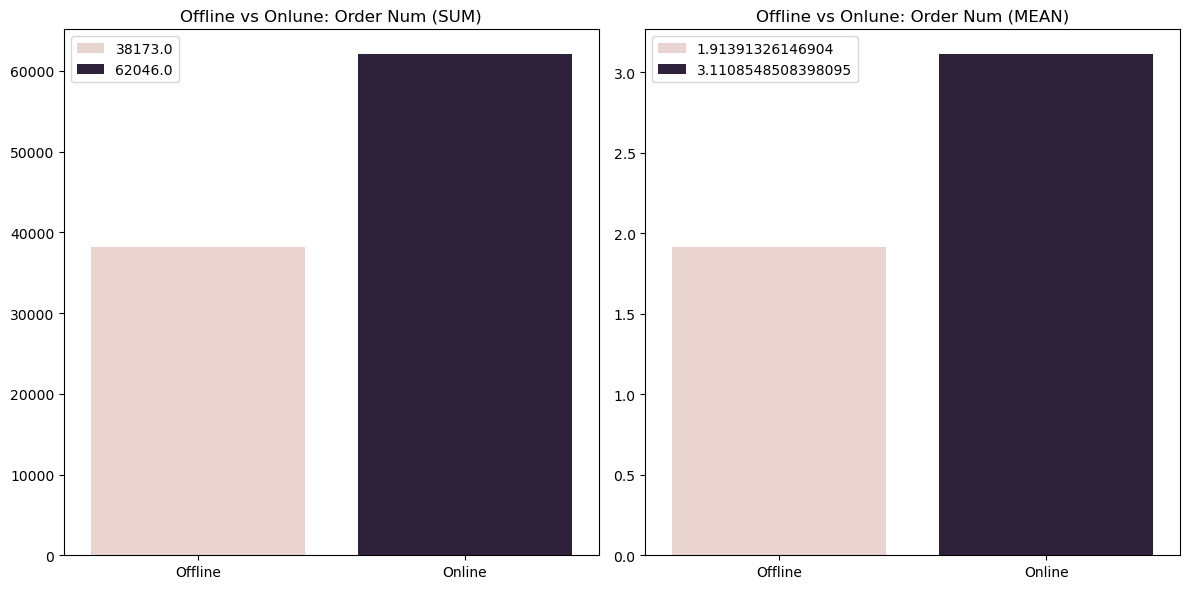

In [12]:
# 1) order num

# sum
off_sum_val = sum(flo_data['order_num_total_ever_offline'].values)
on_sum_val = sum(flo_data['order_num_total_ever_online'].values)

# mean
off_mean_val = np.mean(flo_data['order_num_total_ever_offline'].values)
on_mean_val = np.mean(flo_data['order_num_total_ever_online'].values)

x = ['Offline', 'Online']
y_sum = [off_sum_val, on_sum_val]
y_mean = [off_mean_val, on_mean_val]

plt.figure(figsize=(12, 6))

plt.subplot(1,2,1)
sns.barplot(x=x, y=y_sum, hue=y_sum)
plt.title('Offline vs Onlune: Order Num (SUM)')

plt.subplot(1,2,2)
sns.barplot(x=x, y=y_mean, hue=y_mean)
plt.title('Offline vs Onlune: Order Num (MEAN)')

plt.tight_layout()
plt.show()
# 오프라인보다 온라인 주문 수가 많음

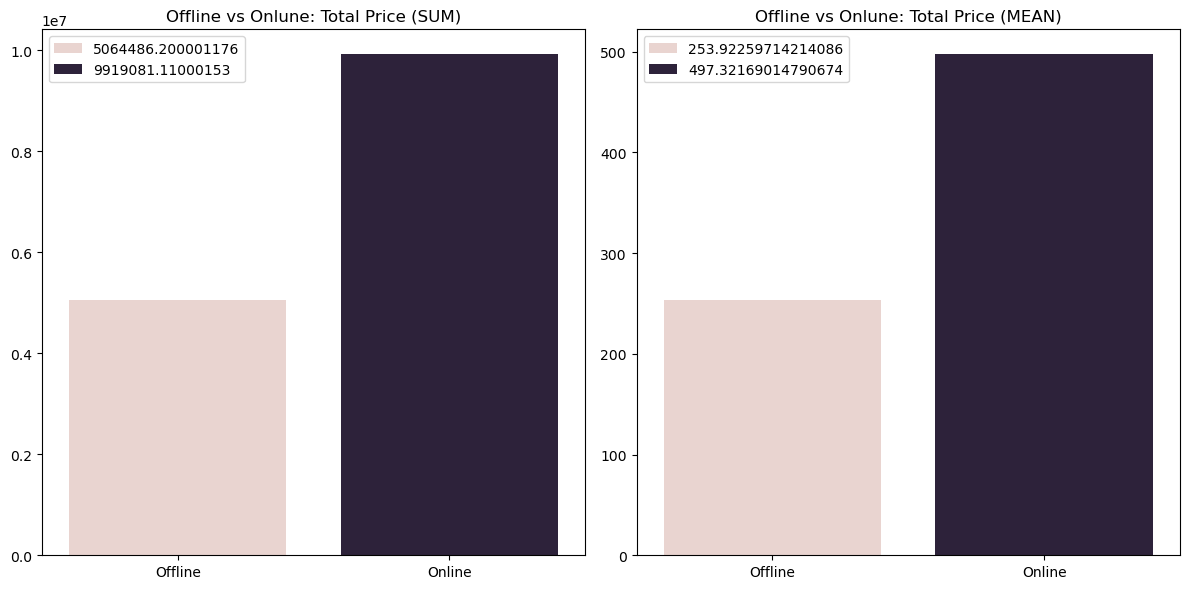

In [13]:
# 2) Total Price

# sum
off_sum_val = sum(flo_data['customer_value_total_ever_offline'].values)
on_sum_val = sum(flo_data['customer_value_total_ever_online'].values)

# mean
off_mean_val = np.mean(flo_data['customer_value_total_ever_offline'].values)
on_mean_val = np.mean(flo_data['customer_value_total_ever_online'].values)

x = ['Offline', 'Online']
y_sum = [off_sum_val, on_sum_val]
y_mean = [off_mean_val, on_mean_val]

plt.figure(figsize=(12, 6))

plt.subplot(1,2,1)
sns.barplot(x=x, y=y_sum, hue=y_sum)
plt.title('Offline vs Onlune: Total Price (SUM)')

plt.subplot(1,2,2)
sns.barplot(x=x, y=y_mean, hue=y_mean)
plt.title('Offline vs Onlune: Total Price (MEAN)')

plt.tight_layout()
plt.show()
# 당연히 오프라인 주문수보다 온라인 주문수가 많기 때문에 금액도 높음

In [14]:
# 3) Last Order Date

offline_series = flo_data.groupby('last_order_date_offline')['master_id'].count().to_frame()
online_series = flo_data.groupby('last_order_date_online')['master_id'].count().to_frame()

# filtering
offline_series = offline_series[offline_series.index > '2020']
online_series = online_series[online_series.index > '2020']

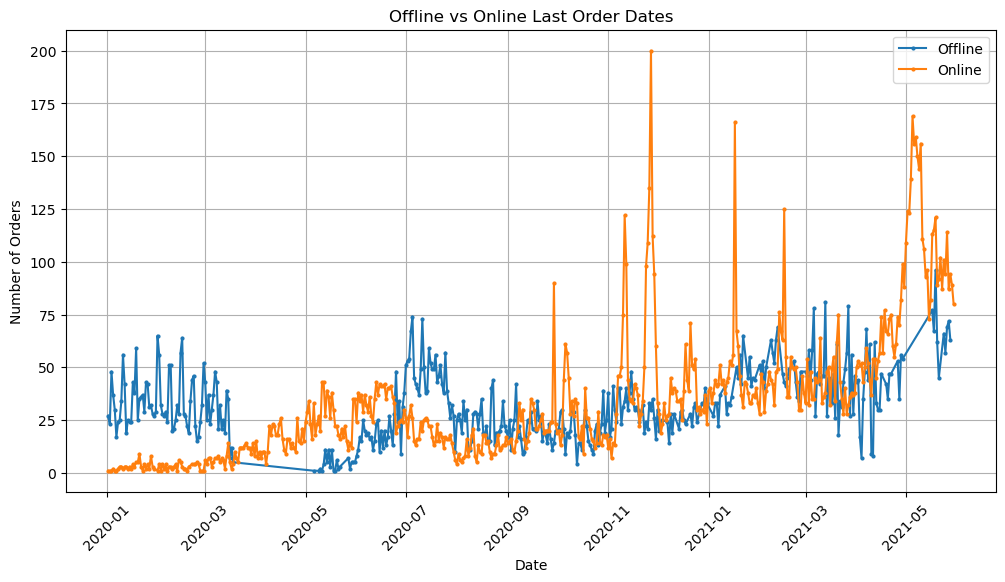

In [15]:
plt.figure(figsize=(12, 6))

plt.plot(offline_series.index, offline_series.values, label='Offline', marker='o', linestyle='-', markersize=2)
plt.plot(online_series.index, online_series.values, label='Online', marker='o', linestyle='-', markersize=2)

plt.xlabel('Date')
plt.ylabel('Number of Orders')
plt.title('Offline vs Online Last Order Dates')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.show()

In [16]:
display(offline_series.head())

offline_series.resample('ME').sum().head()

,master_id
last_order_date_offline,
2020-01-02,27
2020-01-03,23
2020-01-04,48
2020-01-05,37
2020-01-06,30


,master_id
last_order_date_offline,
2020-01-31,989
2020-02-29,992
2020-03-31,502
2020-04-30,0
2020-05-31,87


In [17]:
offline_series = offline_series.resample('ME').sum()
online_series = online_series.resample('ME').sum()

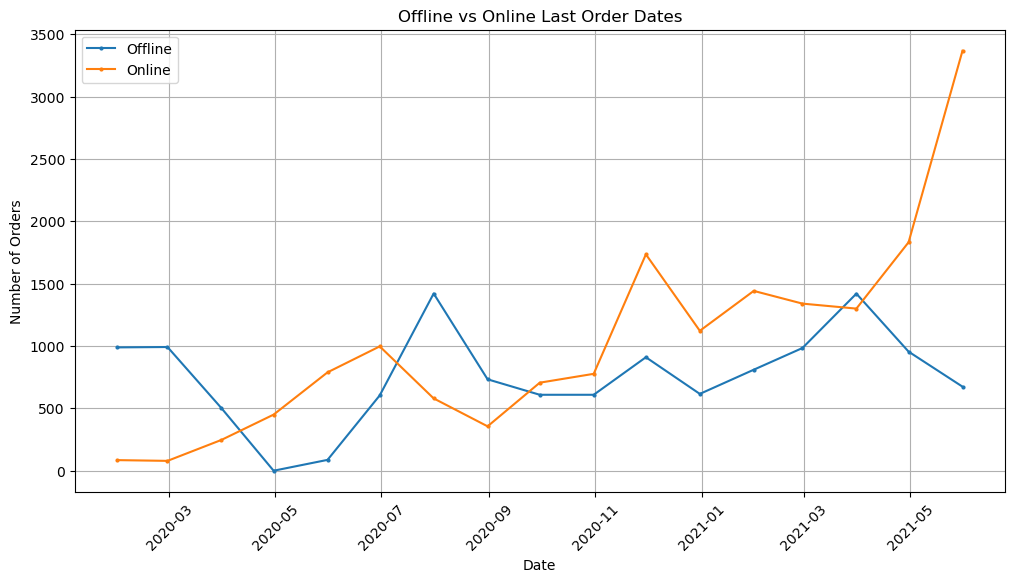

In [18]:
plt.figure(figsize=(12, 6))

plt.plot(offline_series.index, offline_series.values, label='Offline', marker='o', linestyle='-', markersize=2)
plt.plot(online_series.index, online_series.values, label='Online', marker='o', linestyle='-', markersize=2)

plt.xlabel('Date')
plt.ylabel('Number of Orders')
plt.title('Offline vs Online Last Order Dates')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.show()
# 온라인 주문수는 우상향, 오프라인은 편차가 있음

In [19]:
# 4) 요일

flo_data['last_order_day_offline'] = pd.to_datetime(flo_data['last_order_date_offline']).dt.day_name()
flo_data['last_order_day_online'] = pd.to_datetime(flo_data['last_order_date_online']).dt.day_name()
flo_data.head()

,master_id,order_channel,last_order_channel,first_order_date,last_order_date,last_order_date_online,last_order_date_offline,order_num_total_ever_online,order_num_total_ever_offline,customer_value_total_ever_offline,customer_value_total_ever_online,interested_in_categories_12,order_num_total,customer_value_total,interested_in_categories_12_eng,last_order_day_offline,last_order_day_online
0,cc294636-19f0-11eb-8d74-000d3a38a36f,Android App,Offline,2020-10-30,2021-02-26,2021-02-21,2021-02-26,4.0,1.0,139.99,799.38,[KADIN],5.0,939.37,[WOMAN],Friday,Sunday
1,f431bd5a-ab7b-11e9-a2fc-000d3a38a36f,Android App,Mobile,2017-02-08,2021-02-16,2021-02-16,2020-01-10,19.0,2.0,159.97,1853.58,"[ERKEK, COCUK, KADIN, AKTIFSPOR]",21.0,2013.55,"[MAN, CHILD, WOMAN, ACTIVE SPORTS]",Friday,Tuesday
2,69b69676-1a40-11ea-941b-000d3a38a36f,Android App,Android App,2019-11-27,2020-11-27,2020-11-27,2019-12-01,3.0,2.0,189.97,395.35,"[ERKEK, KADIN]",5.0,585.32,"[MAN, WOMAN]",Sunday,Friday
3,1854e56c-491f-11eb-806e-000d3a38a36f,Android App,Android App,2021-01-06,2021-01-17,2021-01-17,2021-01-06,1.0,1.0,39.99,81.98,"[AKTIFCOCUK, COCUK]",2.0,121.97,"[ACTIVE CHILD, CHILD]",Wednesday,Sunday
4,d6ea1074-f1f5-11e9-9346-000d3a38a36f,Desktop,Desktop,2019-08-03,2021-03-07,2021-03-07,2019-08-03,1.0,1.0,49.99,159.99,[AKTIFSPOR],2.0,209.98,[ACTIVE SPORTS],Saturday,Sunday


In [20]:
offline_order_day_counts = flo_data.groupby('last_order_day_offline')['master_id'].count().to_frame()
online_order_day_counts = flo_data.groupby('last_order_day_online')['master_id'].count().to_frame()

display(offline_order_day_counts)
display(online_order_day_counts)

,master_id
last_order_day_offline,
Friday,2793
Monday,2741
Saturday,3201
Sunday,2787
Thursday,2825
Tuesday,2698
Wednesday,2900


,master_id
last_order_day_online,
Friday,2699
Monday,2934
Saturday,2701
Sunday,2990
Thursday,2730
Tuesday,2977
Wednesday,2914


In [21]:
days_of_week = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

offline_order_day_counts = offline_order_day_counts.reindex(days_of_week)
online_order_day_counts = online_order_day_counts.reindex(days_of_week)

display(offline_order_day_counts)
display(online_order_day_counts)

,master_id
last_order_day_offline,
Monday,2741
Tuesday,2698
Wednesday,2900
Thursday,2825
Friday,2793
Saturday,3201
Sunday,2787


,master_id
last_order_day_online,
Monday,2934
Tuesday,2977
Wednesday,2914
Thursday,2730
Friday,2699
Saturday,2701
Sunday,2990


In [22]:
offline_order_day_counts = offline_order_day_counts.reset_index().rename(columns={'master_id': 'order_count'})
online_order_day_counts = online_order_day_counts.reset_index().rename(columns={'master_id': 'order_count'})

display(offline_order_day_counts)
display(online_order_day_counts)

,last_order_day_offline,order_count
0,Monday,2741
1,Tuesday,2698
2,Wednesday,2900
3,Thursday,2825
4,Friday,2793
5,Saturday,3201
6,Sunday,2787


,last_order_day_online,order_count
0,Monday,2934
1,Tuesday,2977
2,Wednesday,2914
3,Thursday,2730
4,Friday,2699
5,Saturday,2701
6,Sunday,2990


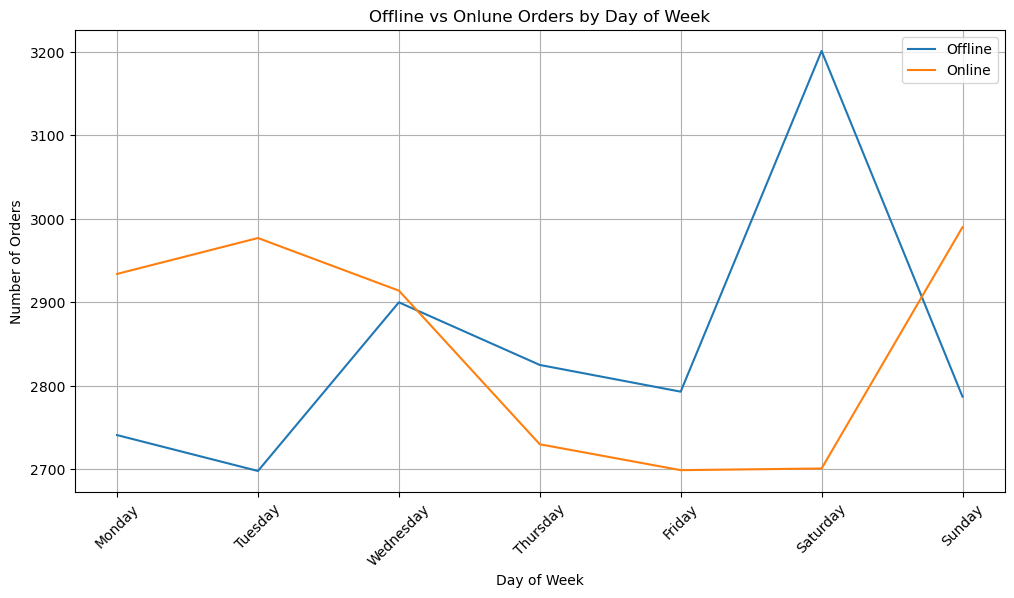

In [23]:
plt.figure(figsize=(12, 6))

sns.lineplot(x=offline_order_day_counts['last_order_day_offline'], y=offline_order_day_counts['order_count'], label='Offline')
sns.lineplot(x=online_order_day_counts['last_order_day_online'], y=online_order_day_counts['order_count'], label='Online')

plt.title('Offline vs Onlune Orders by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Orders')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.show()
# 평일에는 온라인 주문수가 더 많은 반면
# 주말에는 오프라인 주문수가 더 많다.

### **Order Channel**

In [24]:
channel_list = flo_data['last_order_channel'].unique()
channel_list

array(['Offline', 'Mobile', 'Android App', 'Desktop', 'Ios App'],
      dtype=object)

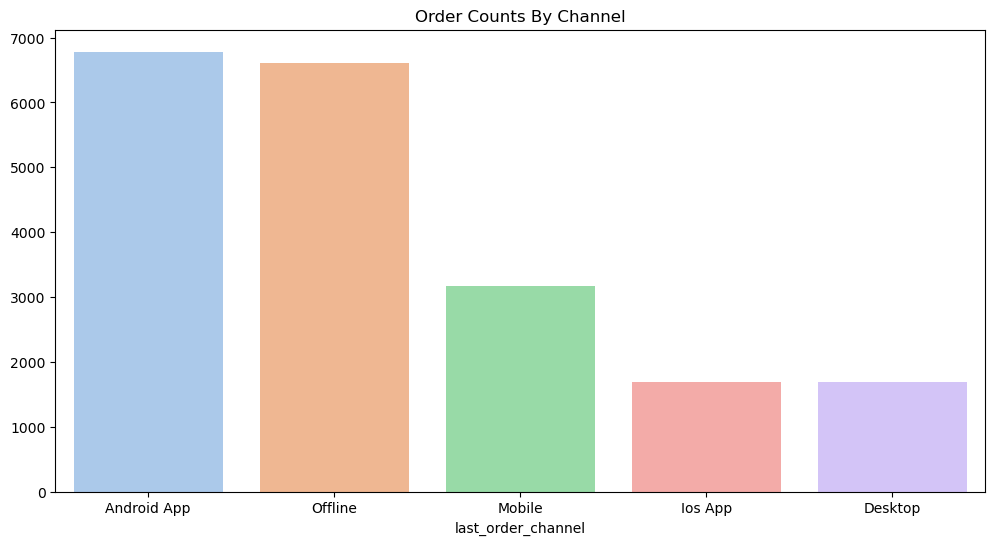

In [25]:
# 채널별 주문수 비교
order_channel_counts = flo_data['last_order_channel'].value_counts()

x = order_channel_counts.index
y = order_channel_counts.values

plt.figure(figsize=(12, 6))

sns.barplot(x=x, y=y, hue=x, palette='pastel')
plt.title('Order Counts By Channel')

plt.show()

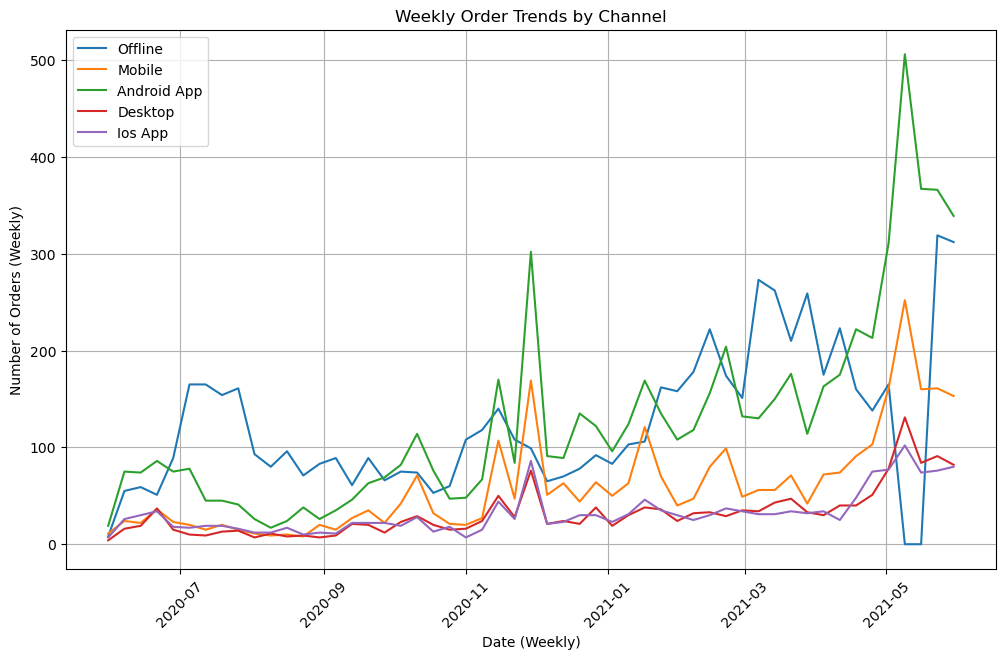

In [26]:
# 시간 경과에 따른 채널별 주문수 비교
channel_groups = flo_data.groupby('last_order_channel')

plt.figure(figsize=(12, 7))

for channel in channel_list:
    channel_data = channel_groups.get_group(channel)

    # 오프라인 채널과 온라인 채널 구분
    if channel == 'Offline':
        channel_data = channel_data.set_index('last_order_date_offline')
        channel_weekly = channel_data.resample('W')['master_id'].count()
    else:
        channel_data = channel_data.set_index('last_order_date_online')
        channel_weekly = channel_data.resample('W')['master_id'].count()

    plt.plot(channel_weekly.index, channel_weekly.values, label=channel)

plt.xlabel('Date (Weekly)')
plt.ylabel('Number of Orders (Weekly)')
plt.title('Weekly Order Trends by Channel')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.show()

In [27]:
# list 형태로 저장되어 있지만 object 타입인 데이터 분리
category_list = []

for categories in flo_data['interested_in_categories_12_eng']:
    categories = categories[1:-1] # 대괄호 제거
    categories = categories.split(', ') # ', ' 기준으로 나누기

    for category in categories:
        category = category.strip()

        if category not in category_list:
            category_list.append(category)
category_list

['WOMAN', 'MAN', 'CHILD', 'ACTIVE SPORTS', 'ACTIVE CHILD', '']

In [28]:
channel_category_count = {}

for channel in channel_list:
    channel_category_count[channel] = {category: 0 for category in category_list}
channel_category_count

{'Offline': {'WOMAN': 0,
  'MAN': 0,
  'CHILD': 0,
  'ACTIVE SPORTS': 0,
  'ACTIVE CHILD': 0,
  '': 0},
 'Mobile': {'WOMAN': 0,
  'MAN': 0,
  'CHILD': 0,
  'ACTIVE SPORTS': 0,
  'ACTIVE CHILD': 0,
  '': 0},
 'Android App': {'WOMAN': 0,
  'MAN': 0,
  'CHILD': 0,
  'ACTIVE SPORTS': 0,
  'ACTIVE CHILD': 0,
  '': 0},
 'Desktop': {'WOMAN': 0,
  'MAN': 0,
  'CHILD': 0,
  'ACTIVE SPORTS': 0,
  'ACTIVE CHILD': 0,
  '': 0},
 'Ios App': {'WOMAN': 0,
  'MAN': 0,
  'CHILD': 0,
  'ACTIVE SPORTS': 0,
  'ACTIVE CHILD': 0,
  '': 0}}

In [29]:
# 채널별 카테고리 주문수 저장
channel_category_data = flo_data[['last_order_channel', 'interested_in_categories_12_eng']]

for index, row in channel_category_data.iterrows():
    channel = row['last_order_channel']
    categories = row['interested_in_categories_12_eng'][1:-1]

    for category in categories.split(', '):
        category = category.strip()
        channel_category_count[channel][category] += 1
channel_category_count

{'Offline': {'WOMAN': 3093,
  'MAN': 2115,
  'CHILD': 1485,
  'ACTIVE SPORTS': 2871,
  'ACTIVE CHILD': 1074,
  '': 496},
 'Mobile': {'WOMAN': 1065,
  'MAN': 806,
  'CHILD': 563,
  'ACTIVE SPORTS': 1344,
  'ACTIVE CHILD': 502,
  '': 472},
 'Android App': {'WOMAN': 2320,
  'MAN': 2573,
  'CHILD': 1506,
  'ACTIVE SPORTS': 3397,
  'ACTIVE CHILD': 1330,
  '': 751},
 'Desktop': {'WOMAN': 574,
  'MAN': 548,
  'CHILD': 293,
  'ACTIVE SPORTS': 774,
  'ACTIVE CHILD': 246,
  '': 224},
 'Ios App': {'WOMAN': 551,
  'MAN': 600,
  'CHILD': 310,
  'ACTIVE SPORTS': 818,
  'ACTIVE CHILD': 285,
  '': 192}}

In [30]:
# 데이터 프레임으로 변환
channel_category_count_df = pd.DataFrame(channel_category_count).T
channel_category_count_df

,WOMAN,MAN,CHILD,ACTIVE SPORTS,ACTIVE CHILD,
Offline,3093,2115,1485,2871,1074,496
Mobile,1065,806,563,1344,502,472
Android App,2320,2573,1506,3397,1330,751
Desktop,574,548,293,774,246,224
Ios App,551,600,310,818,285,192


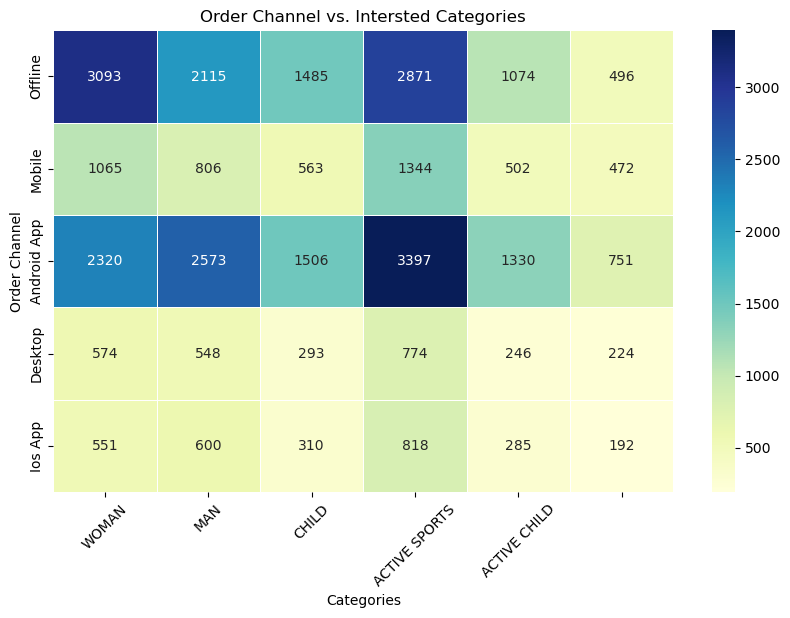

In [31]:
# 채널별 카테고리에 따른 주문수 히트맵 시각화 비교
plt.figure(figsize=(10, 6))
sns.heatmap(channel_category_count_df,
            annot=True,
            fmt='d',
            cmap='YlGnBu',
            linewidths=.5)

plt.title('Order Channel vs. Intersted Categories')
plt.xlabel('Categories')
plt.ylabel('Order Channel')
plt.xticks(rotation=45)
plt.show()

In [32]:
# 묶여있는 카테고리 그대로 비교
nested = flo_data[['last_order_channel', 'interested_in_categories_12_eng']].value_counts()
nested = nested.reset_index()
nested = nested.rename(columns={0: 'count'})
nested = nested.sort_values(by=['last_order_channel', 'count'], ascending=[True, False])
nested.head(10)

,last_order_channel,interested_in_categories_12_eng,count
0,Android App,[ACTIVE SPORTS],1199
3,Android App,[],751
4,Android App,[MAN],735
8,Android App,[WOMAN],511
10,Android App,"[MAN, ACTIVE SPORTS]",483
13,Android App,"[WOMAN, ACTIVE SPORTS]",395
21,Android App,"[MAN, WOMAN, ACTIVE SPORTS]",278
22,Android App,"[MAN, WOMAN]",243
25,Android App,[CHILD],209
26,Android App,[ACTIVE CHILD],208


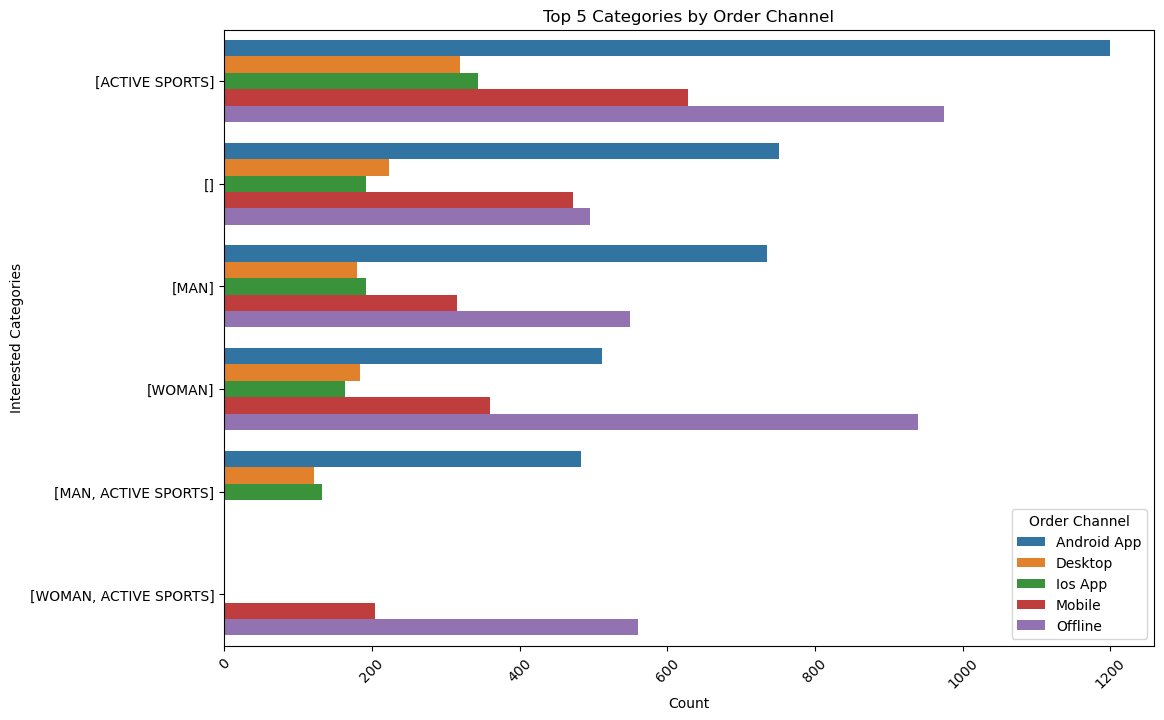

In [33]:
# 상위 5개 카테고리 채널별 주문수 시각화
top_5_categories_by_channel = nested.groupby('last_order_channel').head(5)

plt.figure(figsize=(12, 8))
sns.barplot(x='count', y='interested_in_categories_12_eng', hue='last_order_channel', data=top_5_categories_by_channel)
plt.title('Top 5 Categories by Order Channel')
plt.xlabel('Count')
plt.ylabel('Interested Categories')
plt.xticks(rotation=45)
plt.legend(title='Order Channel')
plt.show()

### **Categories**

In [34]:
categories_count = {category: 0 for category in category_list}
categories_count

{'WOMAN': 0,
 'MAN': 0,
 'CHILD': 0,
 'ACTIVE SPORTS': 0,
 'ACTIVE CHILD': 0,
 '': 0}

In [35]:
for categories in flo_data['interested_in_categories_12_eng']:
    categories = categories[1:-1]
    categories = categories.split(', ')

    for category in categories:
        categories_count[category] += 1
categories_count

{'WOMAN': 7603,
 'MAN': 6642,
 'CHILD': 4157,
 'ACTIVE SPORTS': 9204,
 'ACTIVE CHILD': 3437,
 '': 2135}

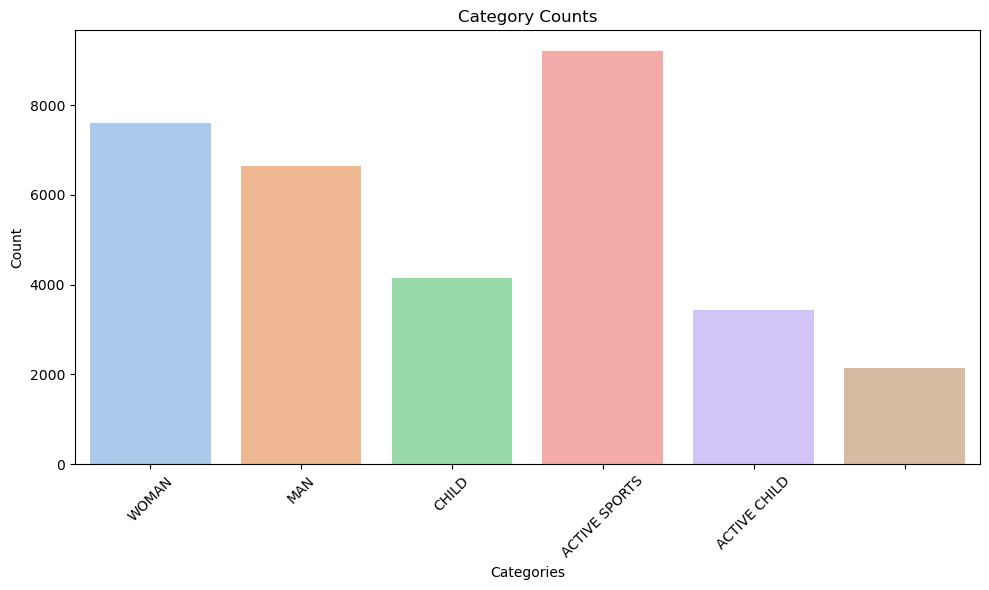

In [36]:
# 카테고리별 주문수 비교
categories = list(categories_count.keys())
counts = list(categories_count.values())

plt.figure(figsize=(10, 6))

sns.barplot(x=categories,
            y=counts,
            hue=categories,
            palette='pastel')

plt.xlabel('Categories')
plt.ylabel('Count')
plt.title('Category Counts')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

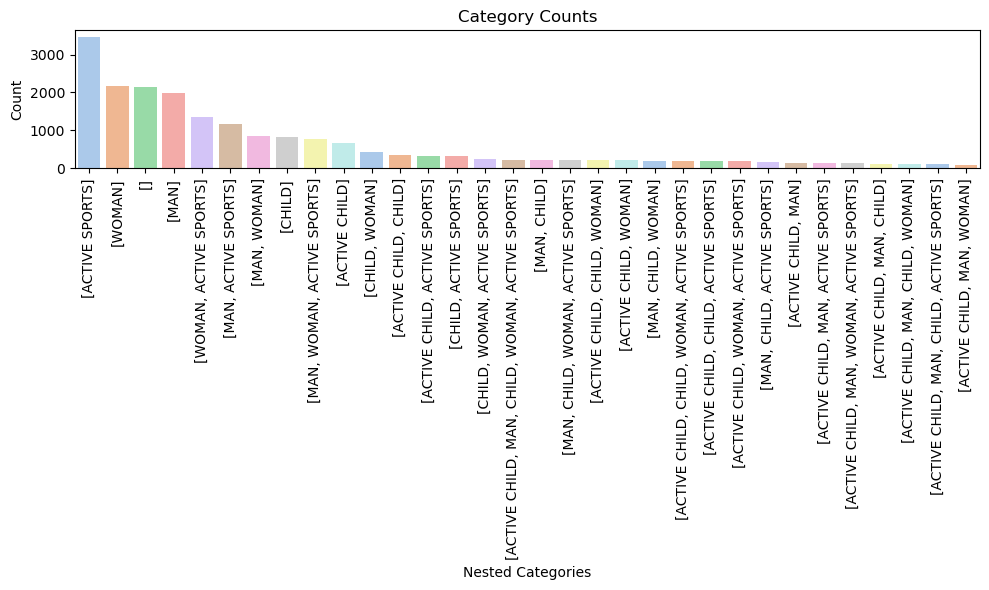

In [37]:
# 묶인 데이터 그대로 비교
nested_categories_count = flo_data['interested_in_categories_12_eng'].value_counts()

categories = list(nested_categories_count.index)
counts = list(nested_categories_count.values)

plt.figure(figsize=(10, 6))

sns.barplot(x=categories,
            y=counts,
            hue=categories,
            palette='pastel')

plt.xlabel('Nested Categories')
plt.ylabel('Count')
plt.title('Category Counts')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

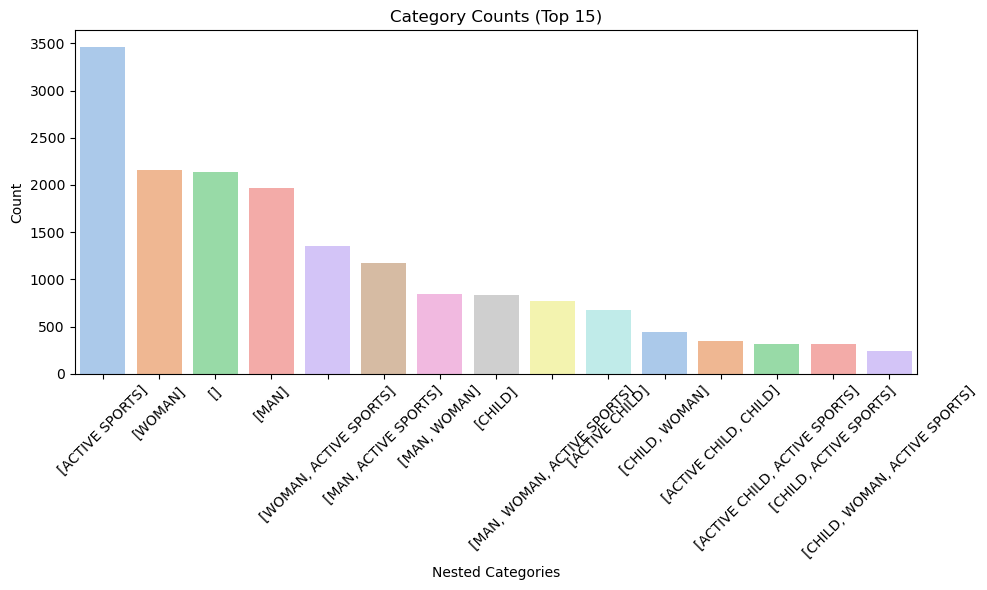

In [38]:
# 상위 15개 묶인 데이터만 비교
# ACTIVE SPORTS 카테고리와 묶인 상품이 많이 주문된 것을 볼 수 있다.
index_top_15 = categories[:15]

nested_categories_count_top_15 = nested_categories_count[index_top_15]

categories = list(nested_categories_count_top_15.index)
counts = list(nested_categories_count_top_15.values)

plt.figure(figsize=(10, 6))

sns.barplot(x=categories,
            y=counts,
            hue=categories,
            palette='pastel')

plt.xlabel('Nested Categories')
plt.ylabel('Count')
plt.title('Category Counts (Top 15)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### **Customer**

In [39]:
# 이상치 확인 (재주문 횟수)
flo_data['order_num_total'].describe()

count    19945.000000
mean         5.024768
std          4.742707
min          2.000000
25%          3.000000
50%          4.000000
75%          6.000000
max        202.000000
Name: order_num_total, dtype: float64

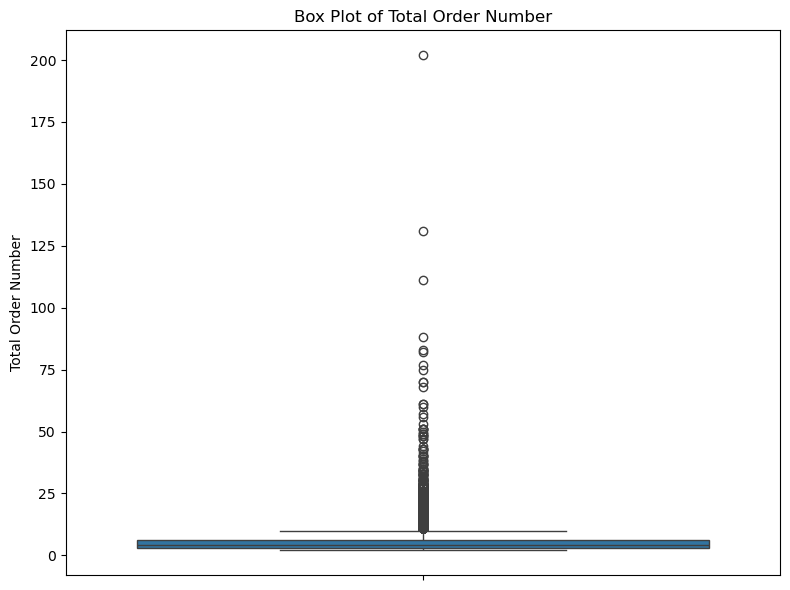

In [40]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=flo_data,
            y='order_num_total')

plt.title('Box Plot of Total Order Number')
plt.ylabel('Total Order Number')

plt.tight_layout()
plt.show()

In [41]:
# 이상치 제거 함수
def remove_outlier(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1

    upper_bound = q3 + (1.5 * iqr)
    lower_bound = q1 - (1.5 * iqr)

    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

In [42]:
flo_data = remove_outlier(flo_data, 'order_num_total')
flo_data['order_num_total'].describe()

count    18546.000000
mean         4.122938
std          2.063951
min          2.000000
25%          2.000000
50%          4.000000
75%          5.000000
max         10.000000
Name: order_num_total, dtype: float64

In [43]:
data = flo_data['order_num_total'].value_counts().reset_index()
data

,order_num_total,count
0,2.0,4717
1,3.0,4377
2,4.0,3127
3,5.0,2145
4,6.0,1515
5,7.0,1053
6,8.0,693
7,9.0,529
8,10.0,390


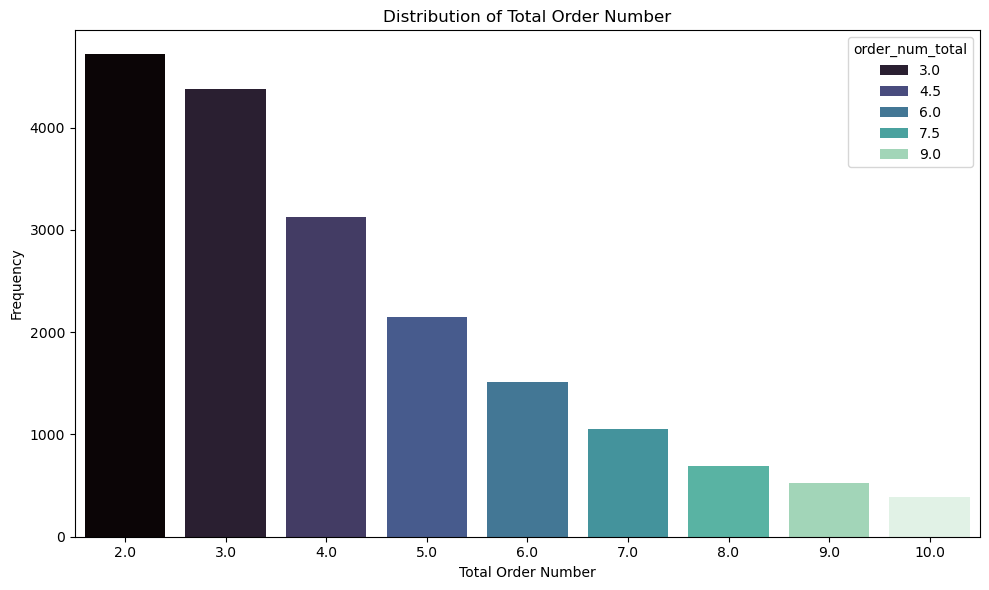

In [44]:
# 한번만 주문한 사람이 없는 것으로 보아 재주문률이 100%인 것을 알 수 있다.
data = flo_data['order_num_total'].value_counts().reset_index()

plt.figure(figsize=(10, 6))

sns.barplot(data=data,
            x='order_num_total',
            y='count',
            hue='order_num_total',
            palette='mako')

plt.title('Distribution of Total Order Number')
plt.xlabel('Total Order Number')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [45]:
# 이상치 확인 (주문 금액 총합)
flo_data['customer_value_total'].describe()

count    18546.000000
mean       622.497358
std        450.073646
min         44.980000
25%        326.750000
50%        511.875000
75%        800.552500
max      20706.340000
Name: customer_value_total, dtype: float64

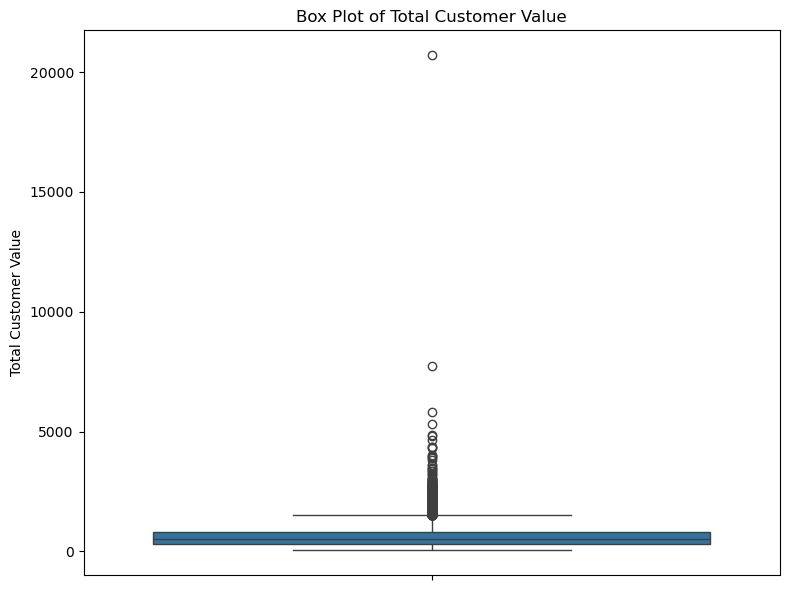

In [46]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=flo_data,
            y='customer_value_total')

plt.title('Box Plot of Total Customer Value')
plt.ylabel('Total Customer Value')

plt.tight_layout()
plt.show()

In [47]:
# 이상치 제거
flo_data = remove_outlier(flo_data, 'customer_value_total')
flo_data['customer_value_total'].describe()

count    17812.000000
mean       566.921361
std        316.530524
min         44.980000
25%        319.970000
50%        495.915000
75%        756.425000
max       1510.080000
Name: customer_value_total, dtype: float64

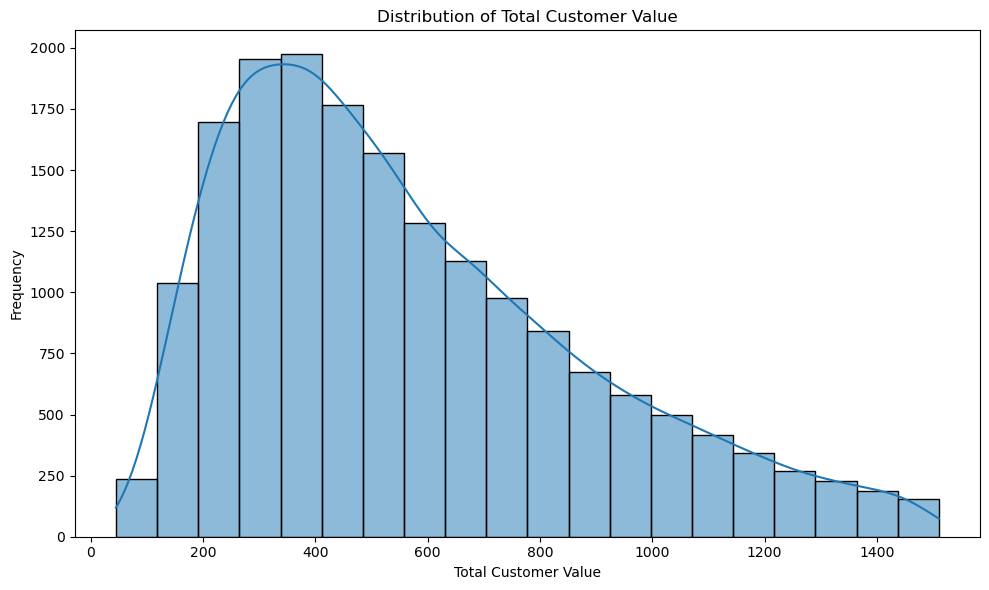

In [48]:
# 분포가 넓기 때문에 히스토그램으로 시각화
# 200 ~ 400에 많이 분포하고 있음
plt.figure(figsize=(10, 6))
sns.histplot(data=flo_data,
             x='customer_value_total',
             bins=20, 
             kde=True)

plt.title('Distribution of Total Customer Value')
plt.xlabel('Total Customer Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [49]:
# 재주문 횟수와 주문 금액 총합의 관계
flo_data[['order_num_total', 'customer_value_total']].head()

,order_num_total,customer_value_total
0,5.0,939.37
2,5.0,585.32
3,2.0,121.97
4,2.0,209.98
5,3.0,200.86


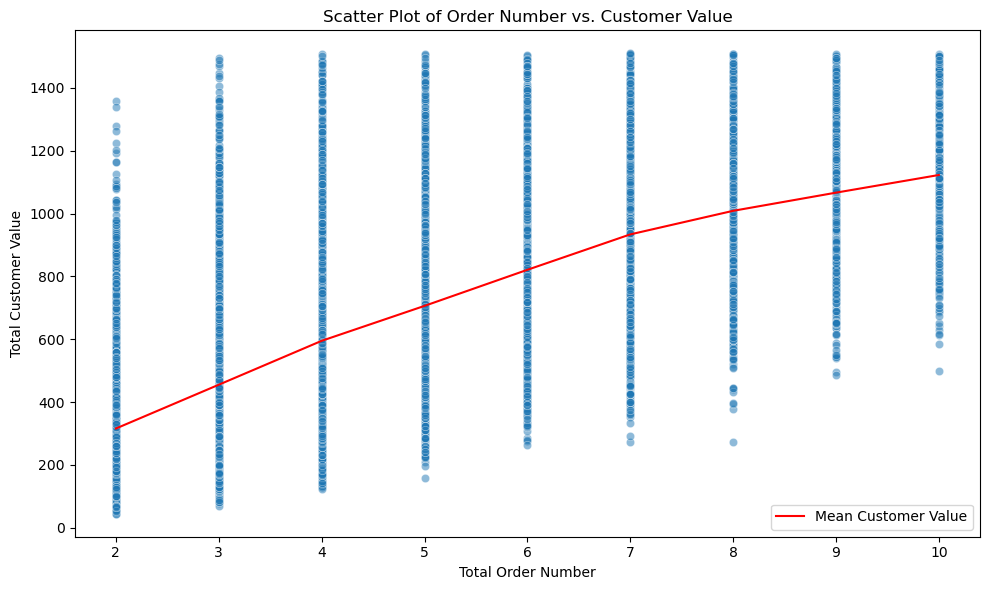

In [50]:
# 많이 주문할수록 평균 금액, 최소 금액이 올라가는 추세이다.
# 하지만 최대 금액은 그렇지 않음.
order_value_avg = flo_data.groupby('order_num_total')['customer_value_total'].mean().reset_index()

plt.figure(figsize=(10, 6))

sns.scatterplot(data=flo_data,
                x='order_num_total',
                y='customer_value_total',
                alpha=0.5)

plt.title('Scatter Plot of Order Number vs. Customer Value')
plt.xlabel('Total Order Number')
plt.ylabel('Total Customer Value')

sns.lineplot(data=order_value_avg,
             x='order_num_total',
             y='customer_value_total',
             color='r',
             ls='-',
             label='Mean Customer Value')
plt.legend()

plt.tight_layout()
plt.show()

In [51]:
# 평균 구매 주기 계산
flo_data['average_order_period'] = (flo_data['last_order_date'] - flo_data['first_order_date']) / flo_data['order_num_total']
flo_data.head()

,master_id,order_channel,last_order_channel,first_order_date,last_order_date,last_order_date_online,last_order_date_offline,order_num_total_ever_online,order_num_total_ever_offline,customer_value_total_ever_offline,customer_value_total_ever_online,interested_in_categories_12,order_num_total,customer_value_total,interested_in_categories_12_eng,last_order_day_offline,last_order_day_online,average_order_period
0,cc294636-19f0-11eb-8d74-000d3a38a36f,Android App,Offline,2020-10-30,2021-02-26,2021-02-21,2021-02-26,4.0,1.0,139.99,799.38,[KADIN],5.0,939.37,[WOMAN],Friday,Sunday,23 days 19:12:00
2,69b69676-1a40-11ea-941b-000d3a38a36f,Android App,Android App,2019-11-27,2020-11-27,2020-11-27,2019-12-01,3.0,2.0,189.97,395.35,"[ERKEK, KADIN]",5.0,585.32,"[MAN, WOMAN]",Sunday,Friday,73 days 04:48:00
3,1854e56c-491f-11eb-806e-000d3a38a36f,Android App,Android App,2021-01-06,2021-01-17,2021-01-17,2021-01-06,1.0,1.0,39.99,81.98,"[AKTIFCOCUK, COCUK]",2.0,121.97,"[ACTIVE CHILD, CHILD]",Wednesday,Sunday,5 days 12:00:00
4,d6ea1074-f1f5-11e9-9346-000d3a38a36f,Desktop,Desktop,2019-08-03,2021-03-07,2021-03-07,2019-08-03,1.0,1.0,49.99,159.99,[AKTIFSPOR],2.0,209.98,[ACTIVE SPORTS],Saturday,Sunday,291 days 00:00:00
5,e585280e-aae1-11e9-a2fc-000d3a38a36f,Desktop,Offline,2018-11-18,2021-03-13,2018-11-18,2021-03-13,1.0,2.0,150.87,49.99,[KADIN],3.0,200.86,[WOMAN],Saturday,Sunday,282 days 00:00:00


In [52]:
# 일 단위로 추출
flo_data['average_order_period_days'] = flo_data['average_order_period'].dt.days
flo_data.head()

,master_id,order_channel,last_order_channel,first_order_date,last_order_date,last_order_date_online,last_order_date_offline,order_num_total_ever_online,order_num_total_ever_offline,customer_value_total_ever_offline,customer_value_total_ever_online,interested_in_categories_12,order_num_total,customer_value_total,interested_in_categories_12_eng,last_order_day_offline,last_order_day_online,average_order_period,average_order_period_days
0,cc294636-19f0-11eb-8d74-000d3a38a36f,Android App,Offline,2020-10-30,2021-02-26,2021-02-21,2021-02-26,4.0,1.0,139.99,799.38,[KADIN],5.0,939.37,[WOMAN],Friday,Sunday,23 days 19:12:00,23
2,69b69676-1a40-11ea-941b-000d3a38a36f,Android App,Android App,2019-11-27,2020-11-27,2020-11-27,2019-12-01,3.0,2.0,189.97,395.35,"[ERKEK, KADIN]",5.0,585.32,"[MAN, WOMAN]",Sunday,Friday,73 days 04:48:00,73
3,1854e56c-491f-11eb-806e-000d3a38a36f,Android App,Android App,2021-01-06,2021-01-17,2021-01-17,2021-01-06,1.0,1.0,39.99,81.98,"[AKTIFCOCUK, COCUK]",2.0,121.97,"[ACTIVE CHILD, CHILD]",Wednesday,Sunday,5 days 12:00:00,5
4,d6ea1074-f1f5-11e9-9346-000d3a38a36f,Desktop,Desktop,2019-08-03,2021-03-07,2021-03-07,2019-08-03,1.0,1.0,49.99,159.99,[AKTIFSPOR],2.0,209.98,[ACTIVE SPORTS],Saturday,Sunday,291 days 00:00:00,291
5,e585280e-aae1-11e9-a2fc-000d3a38a36f,Desktop,Offline,2018-11-18,2021-03-13,2018-11-18,2021-03-13,1.0,2.0,150.87,49.99,[KADIN],3.0,200.86,[WOMAN],Saturday,Sunday,282 days 00:00:00,282


In [53]:
# 이상치 확인
# 만약 현재 데이터가 부동산, 자동차와 관련된 데이터라면
# 4년에 한번씩 구매하는 것이 일반적이지만
# 현재 데이터에서는 그렇지 않음.
flo_data['average_order_period_days'].describe()

count    17812.000000
mean       171.662924
std        142.934339
min          0.000000
25%         86.000000
50%        137.000000
75%        213.000000
max       1302.000000
Name: average_order_period_days, dtype: float64

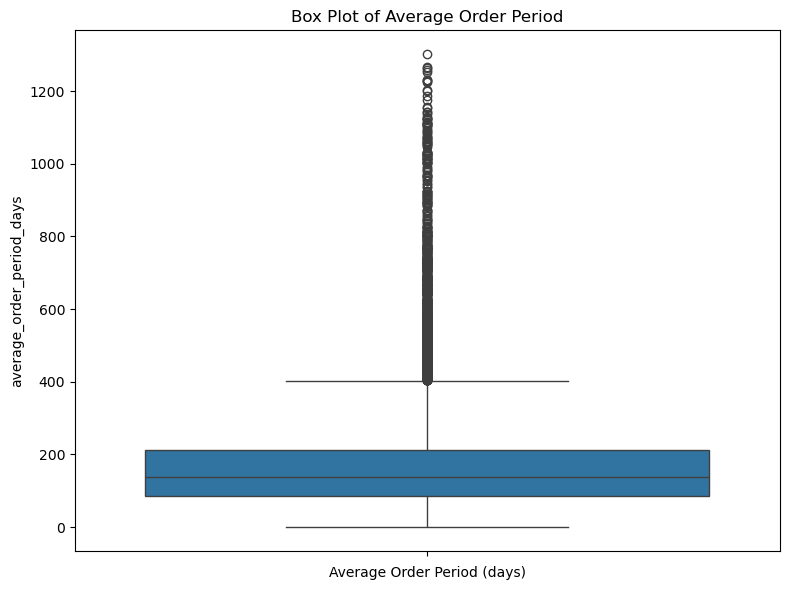

In [54]:
plt.figure(figsize=(8, 6))

sns.boxplot(data=flo_data,
            y='average_order_period_days')

plt.title('Box Plot of Average Order Period')
plt.xlabel('Average Order Period (days)')

plt.tight_layout()
plt.show()

In [55]:
# 이상치 제거
flo_data = remove_outlier(flo_data, 'average_order_period_days')
flo_data['average_order_period_days'].describe()

count    16817.000000
mean       145.813879
std         85.964874
min          0.000000
25%         84.000000
50%        130.000000
75%        195.000000
max        403.000000
Name: average_order_period_days, dtype: float64

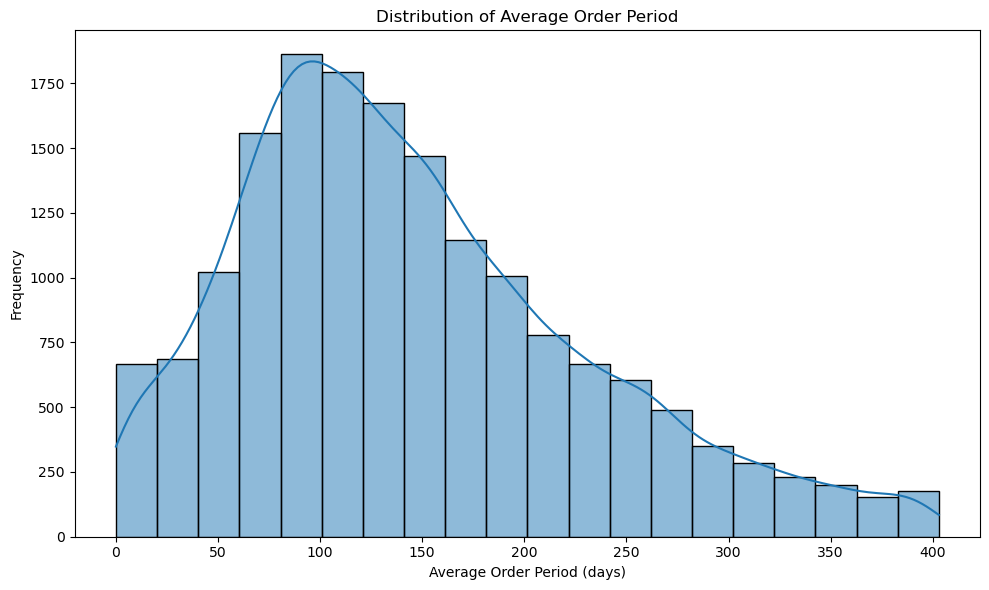

In [56]:
# 50 ~ 150일에 재주문을 많이 하는 것으로 확인됨.
plt.figure(figsize=(10, 6))

sns.histplot(data=flo_data,
             x='average_order_period_days',
             bins=20,
             kde=True)

plt.title('Distribution of Average Order Period')
plt.xlabel('Average Order Period (days)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

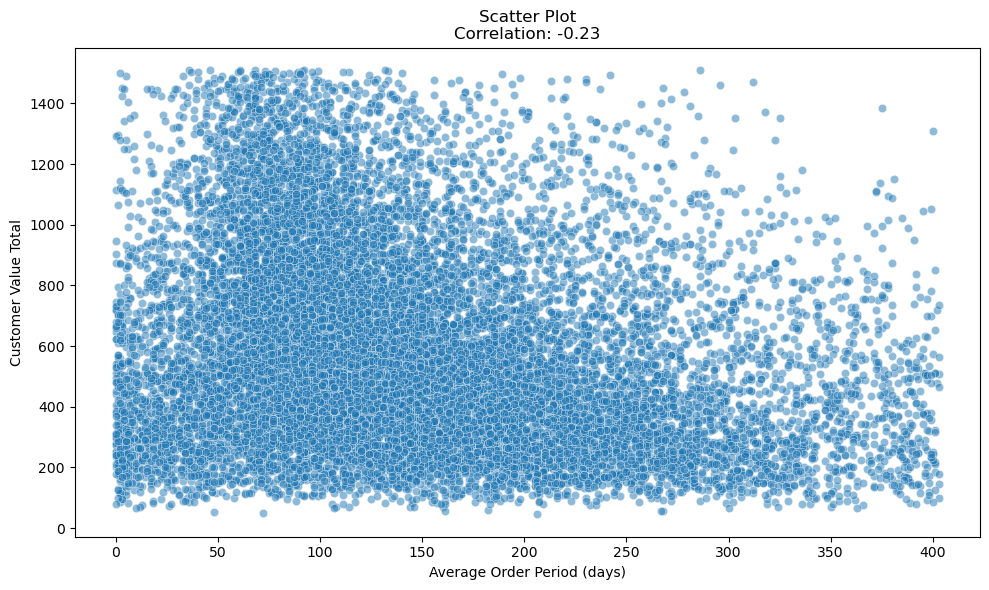

In [57]:
# 평균 구매주기와 총 주문 금액의 상관관계
# 구매주기가 길어지면 구매 금액이 높은 경우가 줄어들긴 하지만
# 구매주기가 짧다고 금액이 높아지진 않는다.
correlation = flo_data['average_order_period_days'].corr(flo_data['customer_value_total'])

plt.figure(figsize=(10, 6))
sns.scatterplot(data=flo_data,
                x='average_order_period_days',
                y='customer_value_total',
                alpha=0.5)

plt.title(f'Scatter Plot\nCorrelation: {correlation:.2f}')
plt.xlabel('Average Order Period (days)')
plt.ylabel('Customer Value Total')

plt.tight_layout()
plt.show()

In [58]:
import warnings
warnings.filterwarnings('ignore')

In [59]:
# 주문 주기를 20개의 구간으로 범주화
bins = 20

flo_data['order_period_category'] = pd.cut(flo_data['average_order_period_days'], bins=bins)

for group in sorted(flo_data['order_period_category'].unique()):
    print(group)

(-0.403, 20.15]
(20.15, 40.3]
(40.3, 60.45]
(60.45, 80.6]
(80.6, 100.75]
(100.75, 120.9]
(120.9, 141.05]
(141.05, 161.2]
(161.2, 181.35]
(181.35, 201.5]
(201.5, 221.65]
(221.65, 241.8]
(241.8, 261.95]
(261.95, 282.1]
(282.1, 302.25]
(302.25, 322.4]
(322.4, 342.55]
(342.55, 362.7]
(362.7, 382.85]
(382.85, 403.0]


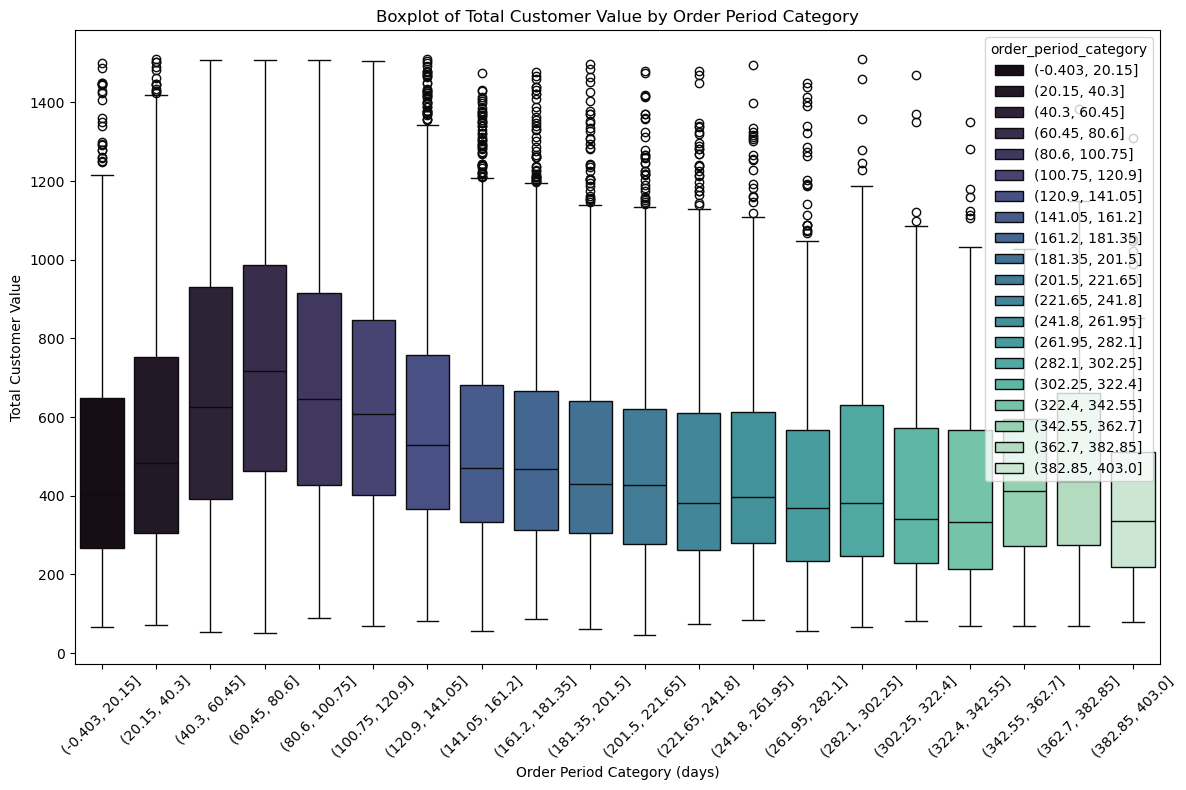

In [60]:
# 3 ~ 5번째 구간이 총 구매 금액의 분포가 높음
# 따라서 40 ~ 100일 구간 고객들이 집중적으로 관리해야할 고객이라고 볼 수 있음.
# 이전의 그룹을 어떻게 이 그룹으로 이동시킬지도 중점
plt.figure(figsize=(12, 8))
sns.boxplot(data=flo_data,
            x='order_period_category',
            y='customer_value_total',
            hue='order_period_category',
            palette='mako')

plt.title('Boxplot of Total Customer Value by Order Period Category')
plt.xlabel('Order Period Category (days)')
plt.ylabel('Total Customer Value')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [61]:
# 60 ~ 80일 사이에 재구매하는 고객의 총 주문 금액이 높았다.
# 따라서 80일 이후를 이탈 시점으로 간주하고
# 80일 이후 세 그룹을 이탈 시점 전에 다시 구매하도록 유도하려고 한다.
groups = sorted(flo_data['order_period_category'].unique())

top_group = groups[3]
target_group = groups[4:7]

print(top_group)
print(target_group)

(60.45, 80.6]
[Interval(80.6, 100.75, closed='right'), Interval(100.75, 120.9, closed='right'), Interval(120.9, 141.05, closed='right')]


In [62]:
top_group_df = flo_data[flo_data['order_period_category'] == top_group]
target_group_df = flo_data[flo_data['order_period_category'].isin(target_group)]

In [63]:
# 그룹별 컬럼 비츌을 확인하기 위한 함수
def get_rate(df, column, num=False):
    total = len(df)
    if num:
        return df[column].value_counts()[:num] / total
    return df[column].value_counts() / total

In [64]:
# 그룹별 채널 비율
top_group_channel_distribution = get_rate(top_group_df, 'last_order_channel')
target_group_channel_distribution = get_rate(target_group_df, 'last_order_channel')

display(top_group_channel_distribution)
display(target_group_channel_distribution)

last_order_channel
Android App    0.391276
Offline        0.320718
Mobile         0.119949
Ios App        0.101988
Desktop        0.066068
Name: count, dtype: float64

last_order_channel
Android App    0.385596
Offline        0.293511
Mobile         0.158290
Ios App        0.087209
Desktop        0.075394
Name: count, dtype: float64

In [65]:
combined_data = pd.DataFrame({'Top Group': top_group_channel_distribution, 'Target Group': target_group_channel_distribution})
combined_data = combined_data.reset_index().rename(columns={'last_order_channel': 'Channel'}).fillna(0)

combined_data

,Channel,Top Group,Target Group
0,Android App,0.391276,0.385596
1,Offline,0.320718,0.293511
2,Mobile,0.119949,0.158290
3,Ios App,0.101988,0.087209
4,Desktop,0.066068,0.075394


In [66]:
combined_data.melt(id_vars='Channel')

,Channel,variable,value
0,Android App,Top Group,0.391276
1,Offline,Top Group,0.320718
2,Mobile,Top Group,0.119949
3,Ios App,Top Group,0.101988
4,Desktop,Top Group,0.066068
5,Android App,Target Group,0.385596
6,Offline,Target Group,0.293511
7,Mobile,Target Group,0.158290
8,Ios App,Target Group,0.087209
9,Desktop,Target Group,0.075394


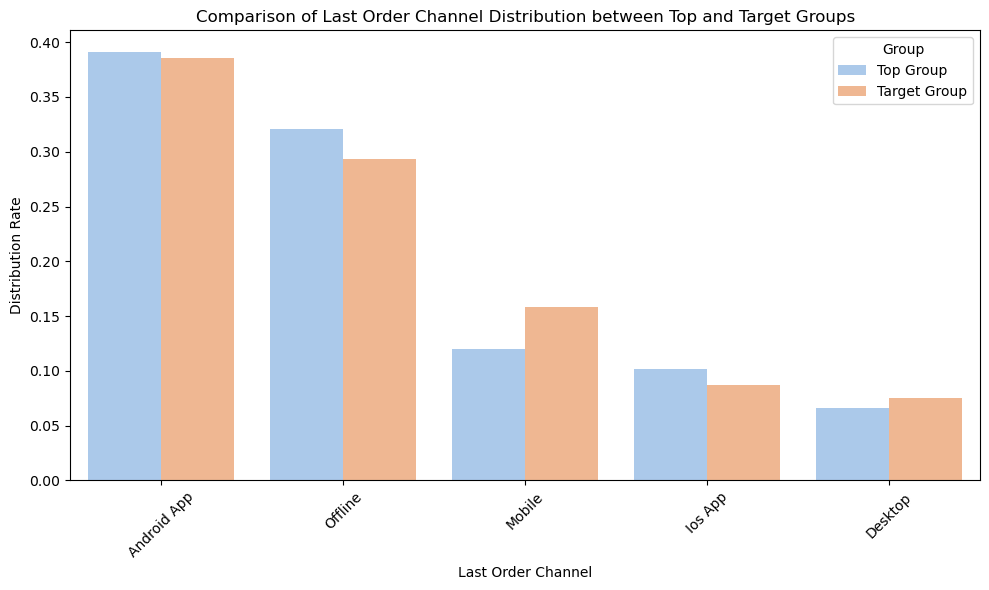

In [67]:
# 막대차트로 비교
# Top 그룹에서는 Target 그룹에 비해 Android, Offline, IOS 채널을 많이 이용하는 것으로 보임
# 어떻게 이러한 채널로 유도할 수 있을까?
plt.figure(figsize=(10, 6))

sns.barplot(data=combined_data.melt(id_vars='Channel'),
            x='Channel',
            y='value',
            hue='variable',
            palette='pastel')

plt.title('Comparison of Last Order Channel Distribution between Top and Target Groups')
plt.xlabel('Last Order Channel')
plt.ylabel('Distribution Rate')
plt.xticks(rotation=45)

plt.legend(title='Group')
plt.tight_layout()
plt.show()

In [68]:
# 그룹별 카테고리 비율 (상위 10개만)
top_group_category_distribution = get_rate(top_group_df, 'interested_in_categories_12_eng', 10)
target_group_category_distribution = get_rate(target_group_df, 'interested_in_categories_12_eng', 10)

display(top_group_category_distribution)
display(target_group_category_distribution)

interested_in_categories_12_eng
[ACTIVE SPORTS]                  0.134060
[MAN]                            0.094291
[WOMAN, ACTIVE SPORTS]           0.093008
[WOMAN]                          0.093008
[MAN, ACTIVE SPORTS]             0.087235
[MAN, WOMAN, ACTIVE SPORTS]      0.075690
[MAN, WOMAN]                     0.055164
[CHILD]                          0.032713
[ACTIVE CHILD]                   0.026299
[CHILD, WOMAN, ACTIVE SPORTS]    0.022450
Name: count, dtype: float64

interested_in_categories_12_eng
[ACTIVE SPORTS]                0.181733
[WOMAN]                        0.102588
[MAN]                          0.102213
[WOMAN, ACTIVE SPORTS]         0.072581
[MAN, ACTIVE SPORTS]           0.066204
[]                             0.066204
[MAN, WOMAN]                   0.048012
[CHILD]                        0.046324
[ACTIVE CHILD]                 0.035446
[MAN, WOMAN, ACTIVE SPORTS]    0.035259
Name: count, dtype: float64

In [69]:
combined_data = pd.DataFrame({'Top Group': top_group_category_distribution, 'Target Group': target_group_category_distribution})
combined_data = combined_data.reset_index().rename(columns={'interested_in_categories_12_eng':'Category'}).fillna(0)

combined_data

,Category,Top Group,Target Group
0,[ACTIVE CHILD],0.026299,0.035446
1,[ACTIVE SPORTS],0.134060,0.181733
2,"[CHILD, WOMAN, ACTIVE SPORTS]",0.022450,0.000000
3,[CHILD],0.032713,0.046324
4,"[MAN, ACTIVE SPORTS]",0.087235,0.066204
5,"[MAN, WOMAN, ACTIVE SPORTS]",0.075690,0.035259
6,"[MAN, WOMAN]",0.055164,0.048012
7,[MAN],0.094291,0.102213
8,"[WOMAN, ACTIVE SPORTS]",0.093008,0.072581
9,[WOMAN],0.093008,0.102588


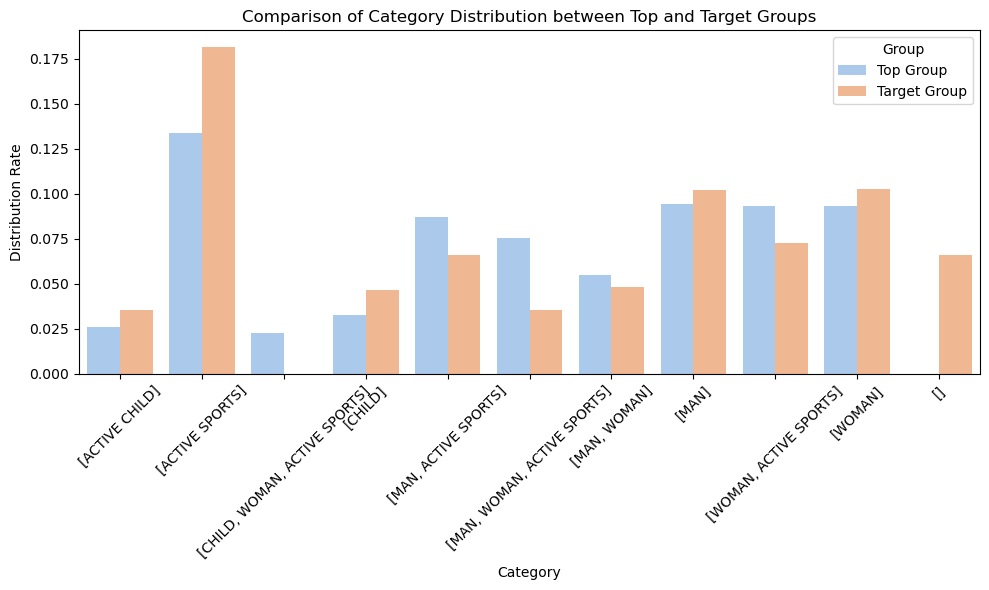

In [70]:
# 막대차트로 비교
# Top 그룹의 경우 여러개의 카테고리를 구메한 것으로 보이고,
# Target 그룹의 경우 하나의 카테고리를 많이 구매한 것으로 나타난다.
# 따라서 Top 그룹과 Target 그룹의 차이는 카테고리 개수로 볼 수 있고,
# 어떻게 하면 여러개의 카테고리를 구매하도록 만들지 고민해야한다.
plt.figure(figsize=(10, 6))

sns.barplot(data=combined_data.melt(id_vars='Category'),
            x='Category',
            y='value',
            hue='variable',
            palette='pastel')

plt.xlabel('Category')
plt.ylabel('Distribution Rate')
plt.title('Comparison of Category Distribution between Top and Target Groups')
plt.xticks(rotation=45)

plt.legend(title='Group')
plt.tight_layout()
plt.show()

In [71]:
# 그룹별 주문 횟수 비율 (상위 10개만)
top_group_order_num_online_distribution = get_rate(top_group_df, 'order_num_total_ever_online', 10)
target_group_order_num_online_distribution = get_rate(target_group_df, 'order_num_total_ever_online', 10)

top_group_order_num_offline_distribution = get_rate(top_group_df, 'order_num_total_ever_offline', 10)
target_group_order_num_offline_distribution = get_rate(target_group_df, 'order_num_total_ever_offline', 10)

In [72]:
combined_data_online = pd.DataFrame({'Top Group': top_group_order_num_online_distribution, 'Target Group': target_group_order_num_online_distribution})
combined_data_online = combined_data_online.reset_index().rename(columns={'order_num_total_ever_online':'Order Num Online'}).fillna(0)

combined_data_offline = pd.DataFrame({'Top Group': top_group_order_num_offline_distribution, 'Target Group': target_group_order_num_offline_distribution})
combined_data_offline = combined_data_offline.reset_index().rename(columns={'order_num_total_ever_offline':'Order Num Offline'}).fillna(0)

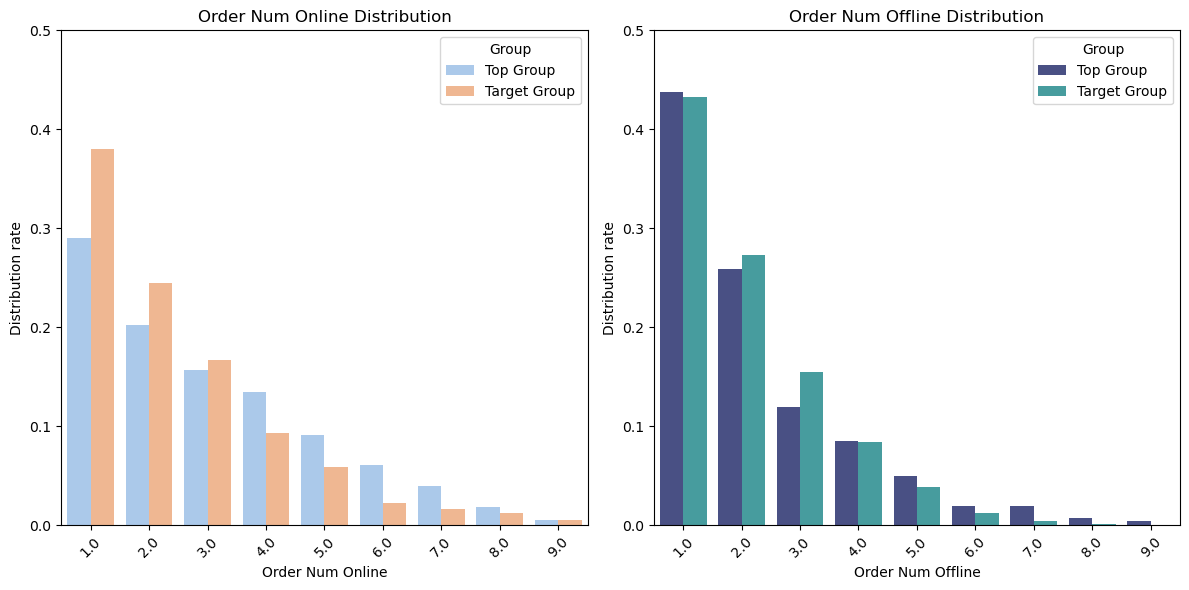

In [73]:
# 막대차트로 비교
# Target 그룹은 올라인에서의 쇼핑 비율이 Top 그룹보다 높고,
# 온라인에서 4회 이상 구매한 경우 Top 그룹이 Target 그룹을 넘어서는 것을 확인할 수 있다.
plt.figure(figsize=(12, 6))

plt.subplot(1,2,1)
sns.barplot(data=combined_data_online.melt(id_vars='Order Num Online'),
            x='Order Num Online',
            y='value',
            hue='variable',
            palette='pastel')

plt.title('Order Num Online Distribution')
plt.xlabel('Order Num Online')
plt.ylabel('Distribution rate')
plt.ylim(0, 0.5)
plt.xticks(rotation=45)
plt.legend(title='Group')

plt.subplot(1,2,2)
sns.barplot(data=combined_data_offline.melt(id_vars='Order Num Offline'),
            x='Order Num Offline',
            y='value',
            hue='variable',
            palette='mako')

plt.title('Order Num Offline Distribution')
plt.xlabel('Order Num Offline')
plt.ylabel('Distribution rate')
plt.ylim(0, 0.5)
plt.xticks(rotation=45)
plt.legend(title='Group')

plt.tight_layout()
plt.show()

## **RFM**

RFM 분석방법은 직관적이고 적용이 쉬운 방법론이지만, <br>
세 변수간의 독립성이 보장되지 않으며, (ex. 자주 구매하는 고객은 구매 금액이 낮더라도 총 구매금액은 높아질 수 밖에 없다.) <br>
분석에 사용할 수 있는 다양한 변수들을 활용하지 못한다는 한계가 있다. <br>

In [74]:
# Recency   마지막(특정) 구매 날짜로부터 지금까지 걸린 시간
# Frequency 특정 기간 구매 횟수
# Monetary  특정 기간 구매 금액

flo_rfm = flo_data.copy(deep=True)

target_date = flo_data['last_order_date'].max()

# RFM 컬럼 추가
flo_rfm['Recency'] = target_date - flo_rfm['last_order_date']
flo_rfm['Recency'] = flo_rfm['Recency'].dt.days
flo_rfm['Frequency'] = flo_rfm['order_num_total']
flo_rfm['Monetary'] = flo_rfm['customer_value_total']

flo_rfm = flo_rfm[['master_id', 'Recency', 'Frequency', 'Monetary']]
flo_rfm.head()

,master_id,Recency,Frequency,Monetary
0,cc294636-19f0-11eb-8d74-000d3a38a36f,93,5.0,939.37
2,69b69676-1a40-11ea-941b-000d3a38a36f,184,5.0,585.32
3,1854e56c-491f-11eb-806e-000d3a38a36f,133,2.0,121.97
4,d6ea1074-f1f5-11e9-9346-000d3a38a36f,84,2.0,209.98
5,e585280e-aae1-11e9-a2fc-000d3a38a36f,78,3.0,200.86


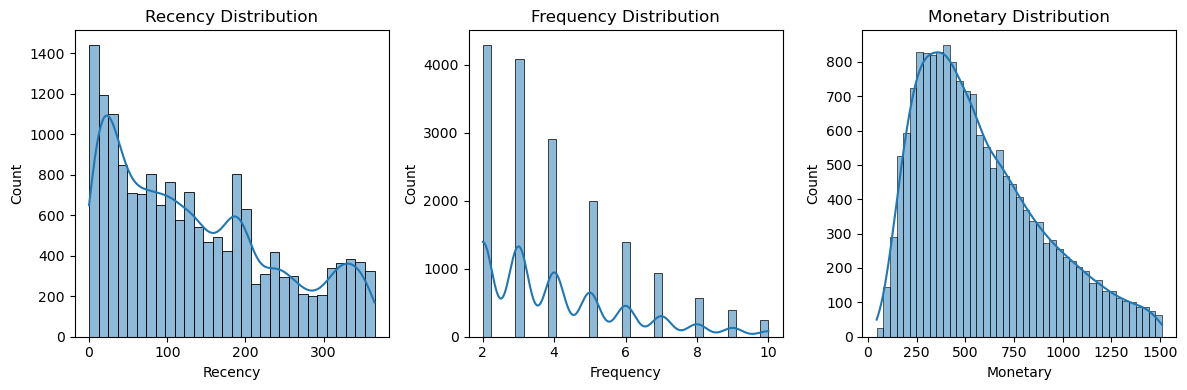

In [75]:
# RFM의 분포 확인
# F와 M의 경우 등급이 높은 고객일수록 우하향,
# 반대로 R의 경우 등급이 높은 구간에 고객들이 많이 존재한다.
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.histplot(data=flo_rfm, x='Recency', kde=True)
plt.title('Recency Distribution')

plt.subplot(1, 3, 2)
sns.histplot(data=flo_rfm, x='Frequency', kde=True)
plt.title('Frequency Distribution')

plt.subplot(1, 3, 3)
sns.histplot(data=flo_rfm, x='Monetary', kde=True)
plt.title('Monetary Distribution')

plt.tight_layout()
plt.show()

In [76]:
# 개별 고객을 각 등급에 할당 (고객 세그멘테이션)

# Recency: 낮을수록 높은 점수
flo_rfm['R'] = pd.qcut(flo_rfm['Recency'],
                       q=5,
                       labels=[5, 4, 3, 2, 1],
                       duplicates='drop')

# Frequency, Monetary: 높을수록 높은 점수
flo_rfm['F'] = pd.qcut(flo_rfm['Frequency'],
                       q=5,
                       labels=[1, 2, 3, 4],
                       duplicates='drop')
flo_rfm['M'] = pd.qcut(flo_rfm['Monetary'],
                       q=5,
                       labels=[1, 2, 3, 4, 5],
                       duplicates='drop')
flo_rfm.head()

,master_id,Recency,Frequency,Monetary,R,F,M
0,cc294636-19f0-11eb-8d74-000d3a38a36f,93,5.0,939.37,3,3,5
2,69b69676-1a40-11ea-941b-000d3a38a36f,184,5.0,585.32,2,3,3
3,1854e56c-491f-11eb-806e-000d3a38a36f,133,2.0,121.97,3,1,1
4,d6ea1074-f1f5-11e9-9346-000d3a38a36f,84,2.0,209.98,4,1,1
5,e585280e-aae1-11e9-a2fc-000d3a38a36f,78,3.0,200.86,4,1,1


In [77]:
flo_rfm['RFM Cell'] = flo_rfm['R'].astype(str) + flo_rfm['F'].astype(str) + flo_rfm['M'].astype(str)
flo_rfm.head()

,master_id,Recency,Frequency,Monetary,R,F,M,RFM Cell
0,cc294636-19f0-11eb-8d74-000d3a38a36f,93,5.0,939.37,3,3,5,335
2,69b69676-1a40-11ea-941b-000d3a38a36f,184,5.0,585.32,2,3,3,233
3,1854e56c-491f-11eb-806e-000d3a38a36f,133,2.0,121.97,3,1,1,311
4,d6ea1074-f1f5-11e9-9346-000d3a38a36f,84,2.0,209.98,4,1,1,411
5,e585280e-aae1-11e9-a2fc-000d3a38a36f,78,3.0,200.86,4,1,1,411


In [78]:
# R, F 기준 등급표
rf_matrix = flo_rfm.groupby(['R', 'F']).agg({
    'master_id': 'count',
    'Monetary': 'sum'
}).reset_index()

rf_matrix['Average Monetary'] = rf_matrix['Monetary'] / rf_matrix['master_id']
rf_matrix

,R,F,master_id,Monetary,Average Monetary
0,5,1,1526,627030.01,410.897779
1,5,2,593,378046.93,637.515902
2,5,3,730,573820.22,786.055096
3,5,4,515,534186.68,1037.255689
4,4,1,1518,617876.80,407.033465
5,4,2,608,358879.15,590.261760
6,4,3,768,601491.62,783.192214
7,4,4,530,542180.16,1022.981434
8,3,1,1671,628933.69,376.381622
9,3,2,582,342492.77,588.475550


In [79]:
# R, F 기준 등급별 사용자 수
rf_pivot = rf_matrix.pivot(
    index='F', columns='R', values='master_id'
).fillna(0).sort_index(ascending=False)
rf_pivot

R,5,4,3,2,1
F,,,,,
4,515,530,405,357,336
3,730,768,653,655,583
2,593,608,582,576,551
1,1526,1518,1671,1783,1877


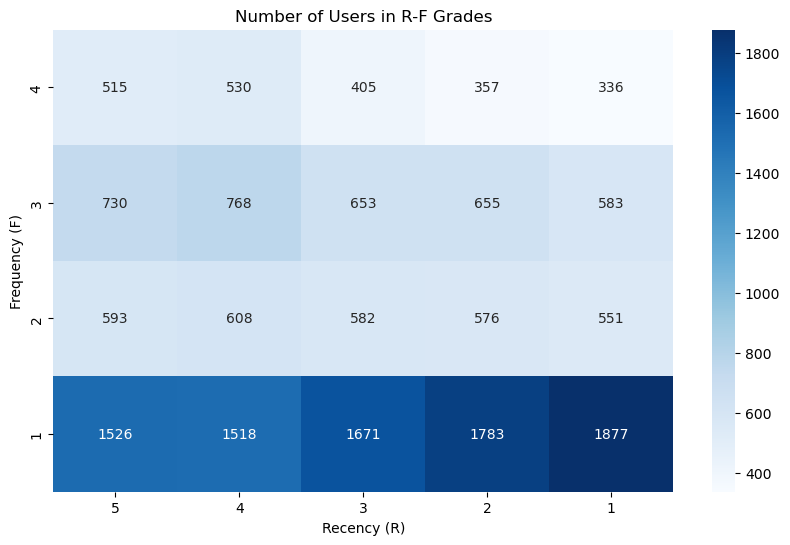

In [80]:
# R, F 기준 등급별 사용자 수 히트맵
# 좌상단으로 갈수록 사용자 수가 적어지는 것을 확인할 수 있다.
plt.figure(figsize=(10, 6))

sns.heatmap(rf_pivot,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title('Number of Users in R-F Grades')
plt.xlabel('Recency (R)')
plt.ylabel('Frequency (F)')
plt.show()

In [81]:
# R, F 기준 등급별 평균구매금액
rf_pivot = rf_matrix.pivot(
    index='F', columns='R', values='Average Monetary'
).fillna(0).sort_index(ascending=False)
rf_pivot

R,5,4,3,2,1
F,,,,,
4,1037.255689,1022.981434,970.424395,1008.503277,938.467798
3,786.055096,783.192214,746.867090,743.481374,714.165609
2,637.515902,590.261760,588.475550,600.086302,585.064991
1,410.897779,407.033465,376.381622,385.807044,361.804305


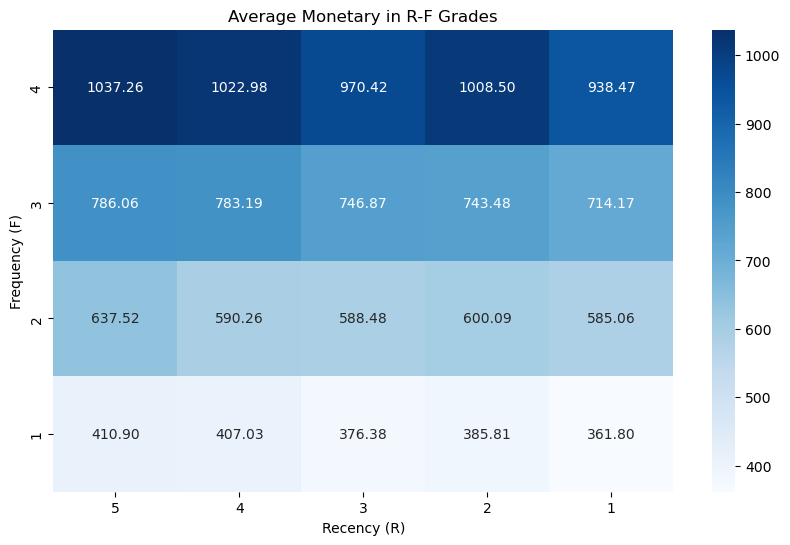

In [82]:
# R, F 기준 등급별 평균구매금액 히트맵
# 좌상단으로 갈수록 평균구매금액이 높아지는 것을 확인할 수 있다.
plt.figure(figsize=(10, 6))

sns.heatmap(rf_pivot,
            annot=True,
            fmt='.2f',
            cmap='Blues')

plt.title('Average Monetary in R-F Grades')
plt.xlabel('Recency (R)')
plt.ylabel('Frequency (F)')
plt.show()

## **CLTV (Customer Lifetime Value)**

### **Metric**

In [83]:
flo_cltv = flo_data.copy()

# 기산 설정
event_start = '2020-01-01'
event_end = '2020-12-31'

# 2020년 데이터만 필터링
flo_cltv = flo_cltv[(flo_cltv['first_order_date'] >= event_start) & (flo_cltv['last_order_date'] <= event_end)].reset_index(drop=True)
flo_cltv.head()

,master_id,order_channel,last_order_channel,first_order_date,last_order_date,last_order_date_online,last_order_date_offline,order_num_total_ever_online,order_num_total_ever_offline,customer_value_total_ever_offline,customer_value_total_ever_online,interested_in_categories_12,order_num_total,customer_value_total,interested_in_categories_12_eng,last_order_day_offline,last_order_day_online,average_order_period,average_order_period_days,order_period_category
0,c445e4ee-6242-11ea-9d1a-000d3a38a36f,Android App,Android App,2020-03-04,2020-10-18,2020-10-18,2020-03-04,3.0,1.0,59.99,315.94,[AKTIFSPOR],4.0,375.93,[ACTIVE SPORTS],Wednesday,Sunday,57 days 00:00:00,57,"(40.3, 60.45]"
1,3f1b4dc8-8a7d-11ea-8ec0-000d3a38a36f,Mobile,Offline,2020-05-15,2020-08-12,2020-05-15,2020-08-12,1.0,1.0,49.99,113.64,[COCUK],2.0,163.63,[CHILD],Wednesday,Friday,44 days 12:00:00,44,"(40.3, 60.45]"
2,ae608ece-c9d8-11ea-a31e-000d3a38a36f,Ios App,Offline,2020-07-19,2020-07-25,2020-07-19,2020-07-25,1.0,1.0,74.99,39.99,"[AKTIFCOCUK, COCUK, KADIN]",2.0,114.98,"[ACTIVE CHILD, CHILD, WOMAN]",Saturday,Sunday,3 days 00:00:00,3,"(-0.403, 20.15]"
3,7a52fd46-5be8-11ea-a7c9-000d3a38a36f,Mobile,Mobile,2020-02-16,2020-07-10,2020-07-10,2020-02-16,1.0,1.0,45.49,89.99,[AKTIFCOCUK],2.0,135.48,[ACTIVE CHILD],Sunday,Friday,72 days 12:00:00,72,"(60.45, 80.6]"
4,c109302c-f72c-11ea-a533-000d3a38a36f,Ios App,Offline,2020-09-15,2020-12-15,2020-09-15,2020-12-15,2.0,1.0,649.99,798.00,[AKTIFSPOR],3.0,1447.99,[ACTIVE SPORTS],Tuesday,Tuesday,30 days 08:00:00,30,"(20.15, 40.3]"


In [84]:
# 지표를 구하는데 쓰이는 전체 고객 수
total = len(flo_cltv)

total, round(total / len(flo_data) * 100, 2)

(1510, 8.98)

In [85]:
# 1) APV, Average Purchase Value
# APV = Total Revenue / Number of Orders
flo_cltv['PV'] = flo_cltv['customer_value_total'] / flo_cltv['order_num_total']

average_pv = sum(flo_cltv['PV']) / total
print(f'Average Purchase Value: {average_pv}')

Average Purchase Value: 155.49978036634081


In [86]:
# 2) APFR, Average Purchase Frequency Rate
# APFR = Number of Purchases / Number of Customers
flo_cltv['frequency'] = flo_cltv['order_num_total']

average_pfr = sum(flo_cltv['frequency']) / total
print(f'Average Purchase Frequency Rate: {average_pfr}')

Average Purchase Frequency Rate: 2.862913907284768


In [87]:
# 3) ACV, Average Customer Value
# CV = Average Purchase Value x Average Purchase Frequency Rate
flo_cltv['CV'] = flo_cltv['PV'] * average_pfr

average_cv = sum(flo_cltv['CV']) / total
print(f'Average Customer Value: {average_cv}')

Average Customer Value: 445.182483790524


In [88]:
# 4) CL, Customer Lifespan
# ACL = Sum of Customer Lifespans / Number of Customers
flo_cltv['CL'] = (flo_cltv['last_order_date'] - flo_cltv['first_order_date']).dt.days

average_cl = sum(flo_cltv['CL']) / total
print(f'Average Customer Lifespan: {average_cl}')

Average Customer Lifespan: 161.32317880794702


In [89]:
# 5) CLTV, Customer Lifetime Value
# CLTV = Customer Value x Average Customer Lifespan
flo_cltv['CLTV'] = flo_cltv['CV'] * flo_cltv['CL']

average_cltv = sum(flo_cltv['CLTV']) / total
print(f'Average Customer Lifetime Value: {average_cltv}')

Average Customer Lifetime Value: 70575.66415520413


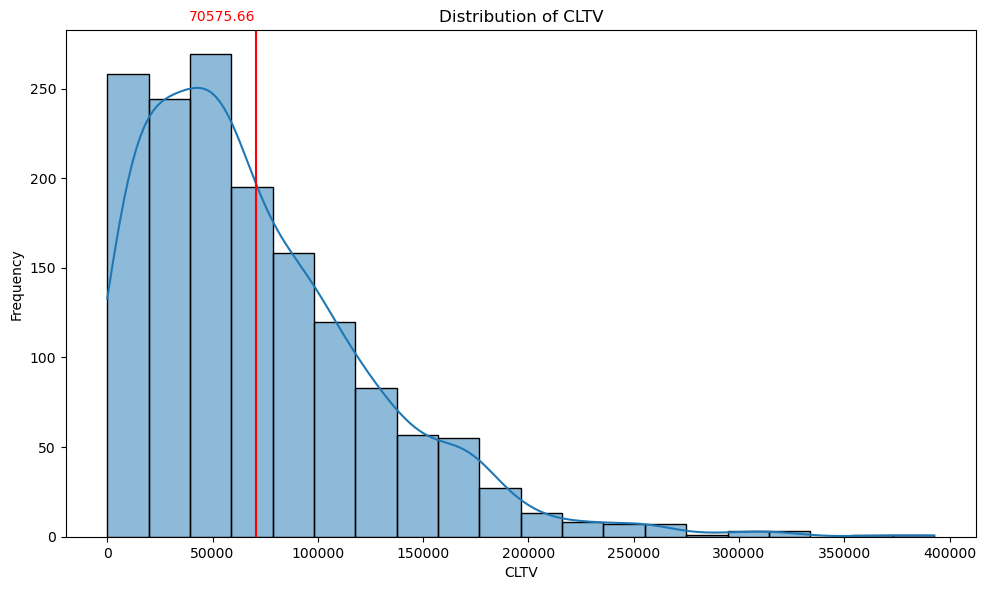

In [90]:
# 평균 생애 가치에 못미치는 고객이 절반 이상된다.
plt.figure(figsize=(10, 6))

sns.histplot(data=flo_cltv,
             x='CLTV',
             bins=20,
             kde=True)

plt.title('Distribution of CLTV')
plt.xlabel('CLTV')
plt.ylabel('Frequency')

plt.axvline(average_cltv,
            color='red',
            ls='-',
            label='Average Customer Lifetime Value')

plt.text(average_cltv,
         290,
         f'{average_cltv:.2f}',
         color='red',
         va='center',
         ha='right')

plt.tight_layout()
plt.show()

In [91]:
# CLTV 기준 고객 세그멘테이션
flo_cltv['segment'] = pd.qcut(flo_cltv['CLTV'],
                              q=5,
                              labels=['E', 'D', 'C', 'B', 'A'])
flo_cltv.head()

,master_id,order_channel,last_order_channel,first_order_date,last_order_date,last_order_date_online,last_order_date_offline,order_num_total_ever_online,order_num_total_ever_offline,customer_value_total_ever_offline,...,last_order_day_online,average_order_period,average_order_period_days,order_period_category,PV,frequency,CV,CL,CLTV,segment
0,c445e4ee-6242-11ea-9d1a-000d3a38a36f,Android App,Android App,2020-03-04,2020-10-18,2020-10-18,2020-03-04,3.0,1.0,59.99,...,Sunday,57 days 00:00:00,57,"(40.3, 60.45]",93.982500,4.0,269.063806,228,61346.547834,C
1,3f1b4dc8-8a7d-11ea-8ec0-000d3a38a36f,Mobile,Offline,2020-05-15,2020-08-12,2020-05-15,2020-08-12,1.0,1.0,49.99,...,Friday,44 days 12:00:00,44,"(40.3, 60.45]",81.815000,2.0,234.229301,89,20846.407818,E
2,ae608ece-c9d8-11ea-a31e-000d3a38a36f,Ios App,Offline,2020-07-19,2020-07-25,2020-07-19,2020-07-25,1.0,1.0,74.99,...,Sunday,3 days 00:00:00,3,"(-0.403, 20.15]",57.490000,2.0,164.588921,6,987.533523,E
3,7a52fd46-5be8-11ea-a7c9-000d3a38a36f,Mobile,Mobile,2020-02-16,2020-07-10,2020-07-10,2020-02-16,1.0,1.0,45.49,...,Friday,72 days 12:00:00,72,"(60.45, 80.6]",67.740000,2.0,193.933788,145,28120.399272,D
4,c109302c-f72c-11ea-a533-000d3a38a36f,Ios App,Offline,2020-09-15,2020-12-15,2020-09-15,2020-12-15,2.0,1.0,649.99,...,Tuesday,30 days 08:00:00,30,"(20.15, 40.3]",482.663333,3.0,1381.823570,91,125745.944828,A


In [93]:
data = np.log10(flo_cltv['CLTV'])
data = [(idx, num) for idx, num in enumerate(data) if num != -np.inf]

x = [num for _, num in data]
idx = [idx for idx, _ in data]

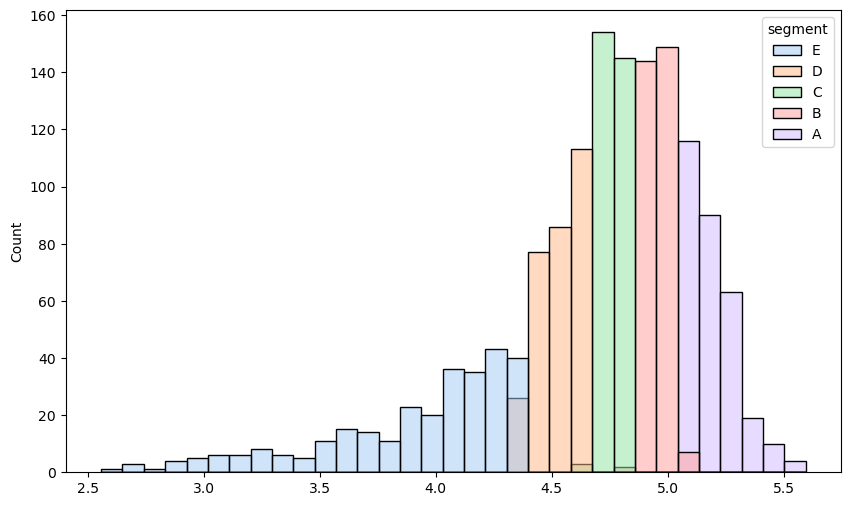

In [94]:
# 데이터 분포의 균형을 맞추고 차이를 줄이기 위해 로그 변환
# B, C, D 구간의 고객들은 편차가 적게 모여있다.
# 반대로 A E 구간의 고객들은 편차가 크게 퍼져있다.
import numpy as np

plt.figure(figsize=(10, 6))

sns.histplot(x=x,
             hue=flo_cltv.iloc[idx]['segment'],
             palette='pastel')

plt.show()

In [95]:
# CLTV 기반 클러스터링
features = ['PV', 'frequency', 'CV', 'CL', 'CLTV']

flo_cluster = flo_cltv.copy()

flo_cluster = flo_cluster[features]
flo_cluster.head()

,PV,frequency,CV,CL,CLTV
0,93.982500,4.0,269.063806,228,61346.547834
1,81.815000,2.0,234.229301,89,20846.407818
2,57.490000,2.0,164.588921,6,987.533523
3,67.740000,2.0,193.933788,145,28120.399272
4,482.663333,3.0,1381.823570,91,125745.944828


In [96]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Scaling
scaler = StandardScaler()
flo_cluster_scaled = scaler.fit_transform(flo_cluster)

# Fit
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(flo_cluster_scaled)

flo_cluster['Cluster'] = kmeans.labels_

In [97]:
from collections import Counter

Counter(kmeans.labels_)

Counter({0: 503, 3: 411, 4: 221, 2: 198, 1: 177})

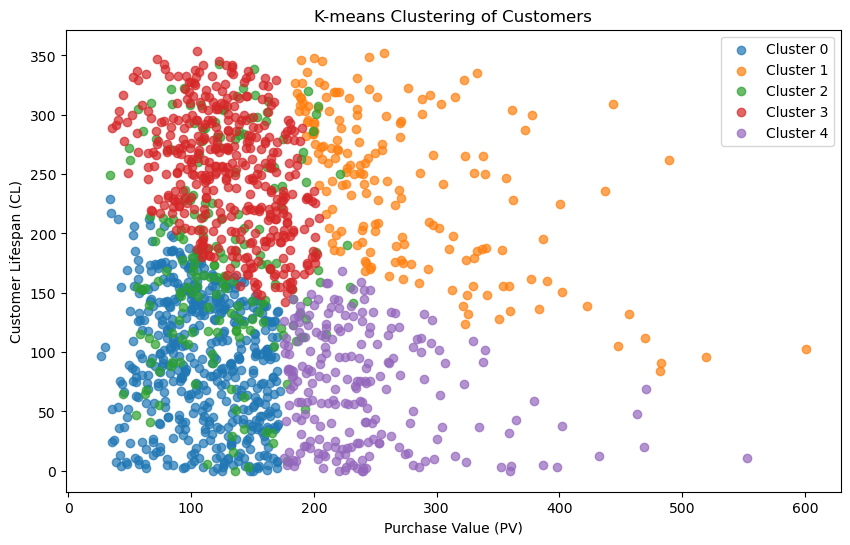

In [ ]:
# 클러스터링 결과 시각화
# cluster 2를 제외한 나머지 cluster는 매우 잘 구분되었다.
# cluster 1은 생애 가치가 높은 중요한 고객들
# 반면에 cluster 0은 생애 가치가 낮은 고객들
plt.figure(figsize=(10, 6))

for cluster_label in range(5):
    cluster_data = flo_cluster[flo_cluster['Cluster'] == cluster_label]
    plt.scatter(cluster_data['PV'],
                cluster_data['CL'],
                label=f'Cluster {cluster_label}',
                alpha=0.7)

plt.title('K-means Clustering of Customers')
plt.xlabel('Purchase Value (PV)')
plt.ylabel('Customer Lifespan (CL)')

plt.legend()
plt.show()

In [99]:
cluster_one = flo_cluster[flo_cluster['Cluster'] == 1]
cluster_one.head()

,PV,frequency,CV,CL,CLTV,Cluster
4,482.663333,3.0,1381.823570,91,125745.944828,1
7,222.656667,3.0,637.446868,241,153624.695079,1
19,285.796667,3.0,818.211252,158,129277.377762,1
40,251.977500,4.0,721.389889,209,150770.486816,1
42,184.355000,2.0,527.792493,327,172588.145334,1


In [ ]:
# 클러스터 기반 중요도가 높은 고객 수
flo_cltv.iloc[cluster_one.index]['segment'].value_counts()

segment
A    177
E      0
D      0
C      0
B      0
Name: count, dtype: int64

### **Top 10**

In [102]:
# CLTV Top 10 고객
columns = ['master_id', 'order_channel', 'interested_in_categories_12_eng',
           'customer_value_total', 'PV', 'frequency', 'CV', 'CL', 'CLTV', 'segment']

flo_cltv_top_10 = flo_cltv.sort_values(by='CLTV', ascending=False)[columns].head(10).reset_index(drop=True)
flo_cltv_top_10

,master_id,order_channel,interested_in_categories_12_eng,customer_value_total,PV,frequency,CV,CL,CLTV,segment
0,9e1c69b6-5bec-11ea-8865-000d3a38a36f,Ios App,[ACTIVE SPORTS],887.98,443.990000,2.0,1271.105146,309,392771.490020,A
1,149bd118-5fcf-11ea-8dd8-000d3a38a36f,Mobile,[WOMAN],977.99,488.995000,2.0,1399.950586,262,366787.053556,A
2,13baebb4-5bd6-11ea-ab15-000d3a38a36f,Mobile,[ACTIVE SPORTS],754.97,377.485000,2.0,1080.707056,300,324212.116887,A
3,f9434dc0-5bf4-11ea-8df6-000d3a38a36f,Android App,"[WOMAN, ACTIVE SPORTS]",998.90,332.966667,3.0,953.254901,335,319340.391722,A
4,6c3cda14-6184-11ea-8dd8-000d3a38a36f,Mobile,"[WOMAN, ACTIVE SPORTS]",722.79,361.395000,2.0,1034.642772,304,314531.402543,A
5,15872818-5fd7-11ea-8dd8-000d3a38a36f,Mobile,"[WOMAN, ACTIVE SPORTS]",1486.29,371.572500,4.0,1063.780078,287,305304.882333,A
6,d82156f0-5b22-11ea-ae74-000d3a38a36f,Android App,"[MAN, CHILD, WOMAN, ACTIVE SPORTS]",967.15,322.383333,3.0,922.955728,329,303652.434669,A
7,86314d0e-6f7d-11ea-b40c-000d3a38a36f,Ios App,[ACTIVE SPORTS],1311.95,437.316667,3.0,1251.999967,236,295471.992185,A
8,65e0481a-5bb0-11ea-b719-000d3a38a36f,Mobile,"[MAN, CHILD]",1259.34,314.835000,4.0,901.345500,315,283923.832500,A
9,0a6933d8-b0a8-11e9-9757-000d3a38a36f,Android App,[ACTIVE SPORTS],606.95,303.475000,2.0,868.822798,309,268466.244586,A


In [103]:
# 주문 채널 수
print(flo_cltv_top_10['order_channel'].value_counts(), '\n')

# 카테고리 수
print(flo_cltv_top_10['interested_in_categories_12_eng'].value_counts())

order_channel
Mobile         5
Android App    3
Ios App        2
Name: count, dtype: int64 

interested_in_categories_12_eng
[ACTIVE SPORTS]                       4
[WOMAN, ACTIVE SPORTS]                3
[WOMAN]                               1
[MAN, CHILD, WOMAN, ACTIVE SPORTS]    1
[MAN, CHILD]                          1
Name: count, dtype: int64


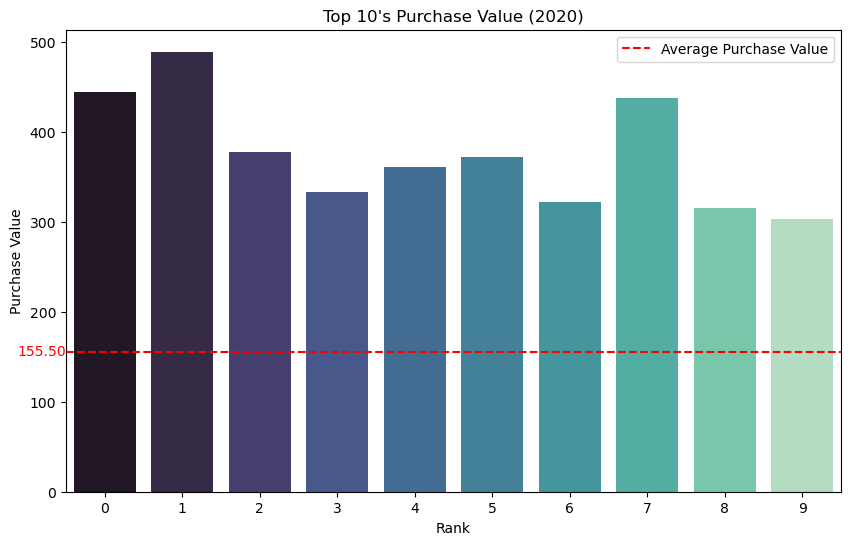

In [ ]:
# PV
# 대체적으로 상위 10위 고객들은 평균 PV보다 2배 이상 높은 값을 가짐
plt.figure(figsize=(10, 6))

sns.barplot(data=flo_cltv_top_10,
            x=flo_cltv_top_10.index,
            y='PV',
            palette='mako')

plt.title("Top 10's Purchase Value (2020)")
plt.xlabel('Rank')
plt.ylabel('Purchase Value')

plt.axhline(average_pv,
            color='red',
            ls='--',
            label='Average Purchase Value')

plt.text(-0.5,
         average_pv,
         f'{average_pv:.2f}',
         color='red',
         va='center',
         ha='right')

plt.legend()
plt.show()

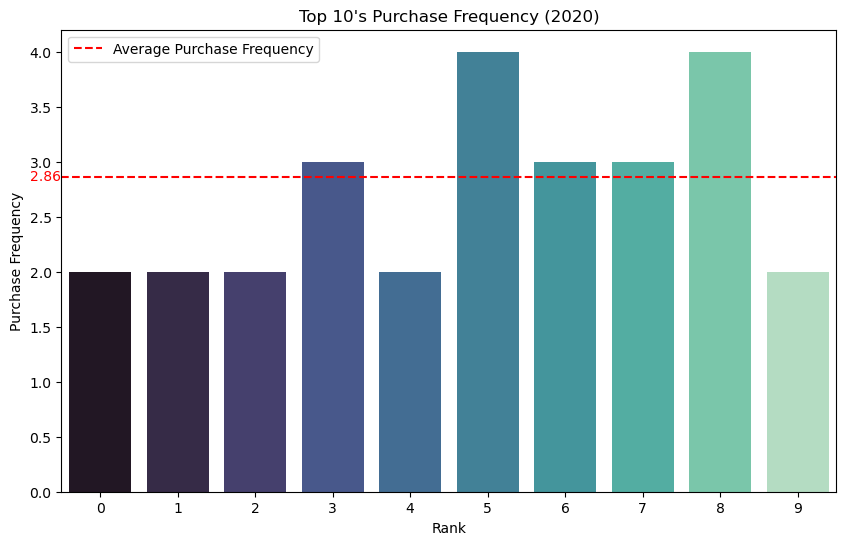

In [ ]:
# PF
# 구매 빈도는 오히려 평균에 못미치는 경우가 많음
# 따라서 반드시 구매 빈도가 높다고 CLTV를 가진다고 할 수 없음
plt.figure(figsize=(10, 6))

sns.barplot(data=flo_cltv_top_10,
            x=flo_cltv_top_10.index,
            y='frequency',
            palette='mako')

plt.title("Top 10's Purchase Frequency (2020)")
plt.xlabel('Rank')
plt.ylabel('Purchase Frequency')

plt.axhline(average_pfr,
            color='red',
            ls='--',
            label='Average Purchase Frequency')

plt.text(-0.5,
         average_pfr,
         f'{average_pfr:.2f}',
         color='red',
         va='center',
         ha='right')

plt.legend()
plt.show()

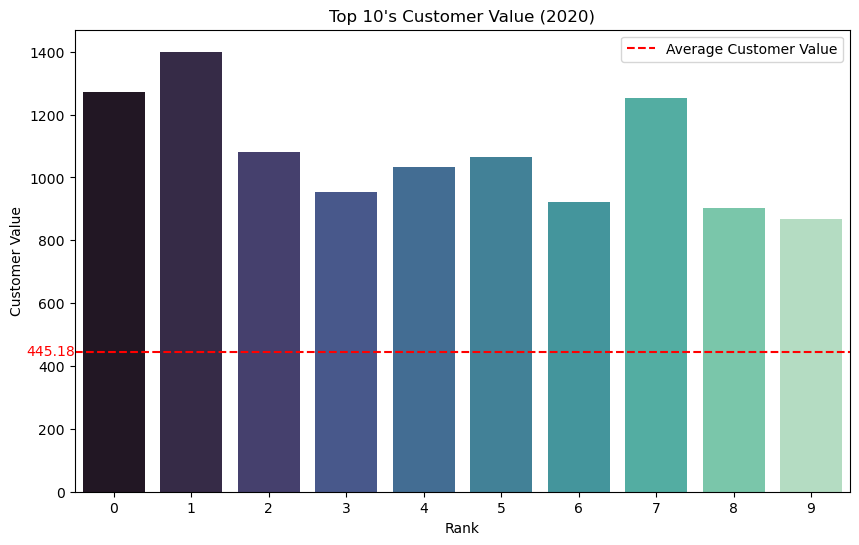

In [ ]:
# CV
# 고객 가치는 평균보다 2배 이상 높은 수치를 가짐
plt.figure(figsize=(10, 6))

sns.barplot(data=flo_cltv_top_10,
            x=flo_cltv_top_10.index,
            y='CV',
            palette='mako')

plt.title("Top 10's Customer Value (2020)")
plt.xlabel('Rank')
plt.ylabel('Customer Value')

plt.axhline(average_cv,
            color='red',
            ls='--',
            label='Average Customer Value')

plt.text(-0.5,
         average_cv,
         f'{average_cv:.2f}',
         color='red',
         va='center',
         ha='right')

plt.legend()
plt.show()

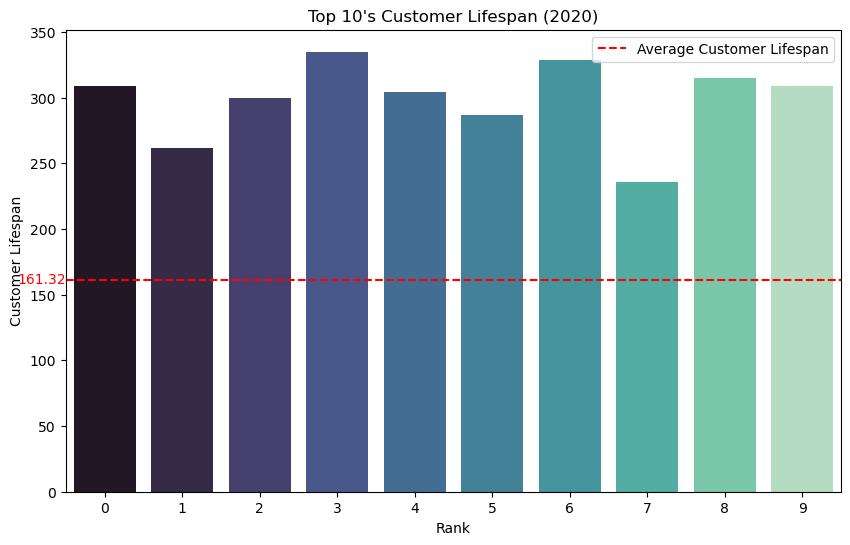

In [107]:
# CL
# 고객 수명도 평균에 비해서 높은 수치를 가짐
plt.figure(figsize=(10, 6))

sns.barplot(data=flo_cltv_top_10,
            x=flo_cltv_top_10.index,
            y='CL',
            palette='mako')

plt.title("Top 10's Customer Lifespan (2020)")
plt.xlabel('Rank')
plt.ylabel('Customer Lifespan')

plt.axhline(average_cl,
            color='red',
            ls='--',
            label='Average Customer Lifespan')

plt.text(-0.5,
         average_cl,
         f'{average_cl:.2f}',
         color='red',
         va='center',
         ha='right')

plt.legend()
plt.show()

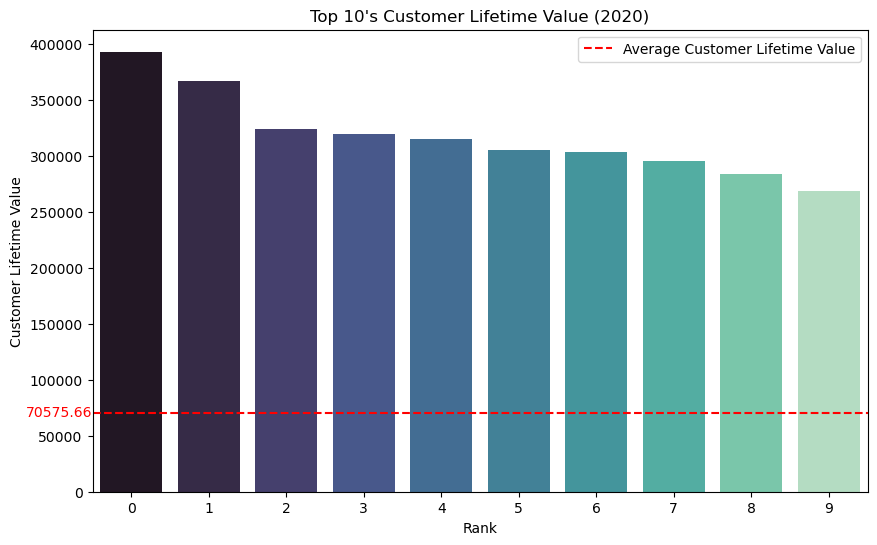

In [108]:
# CLTV
# CLTV가 가장 압도적인 수치를 가지며,
# 대체적으로 4배 이상 높은 수치가 관찰됨.
plt.figure(figsize=(10, 6))

sns.barplot(data=flo_cltv_top_10,
            x=flo_cltv_top_10.index,
            y='CLTV',
            palette='mako')

plt.title("Top 10's Customer Lifetime Value (2020)")
plt.xlabel('Rank')
plt.ylabel('Customer Lifetime Value')

plt.axhline(average_cltv,
            color='red',
            ls='--',
            label='Average Customer Lifetime Value')

plt.text(-0.5,
         average_cltv,
         f'{average_cltv:.2f}',
         color='red',
         va='center',
         ha='right')

plt.legend()
plt.show()

### **Lifetimes**

위에서 직접 구했던 지표들을 구해주는 오픈소스 라이브러리

In [110]:
flo_cltv2 = flo_data.copy()

target_date = flo_data['last_order_date'].max()
target_date

Timestamp('2021-05-30 00:00:00')

In [111]:
# 모델에 필요한 지표 구하기
# F(freqeuncy)      고객 별 구매 횟수
# R(recency)        고객 별 첫 구매 ~ 마지막 구매까지의 시간
# T                 고객 별 첫 구매 ~ 집계일까지의 시간
# M(monetary value) 고객 별 평균 구매 금액
flo_cltv2['frequency'] = flo_cltv2['order_num_total']
flo_cltv2['recency'] = flo_cltv2['last_order_date'] - flo_cltv2['first_order_date']
flo_cltv2['T'] = target_date - flo_cltv2['first_order_date']
flo_cltv2['monetary'] = flo_cltv2['customer_value_total'] / flo_cltv2['order_num_total']

In [112]:
# recency를 주차별로 재설정
flo_cltv2['recency'] = flo_cltv2['recency'].dt.days
flo_cltv2['T'] = flo_cltv2['T'].dt.days

flo_cltv2['recency'] = flo_cltv2['recency'] / 7
flo_cltv2['T'] = flo_cltv2['T'] / 7

In [113]:
flo_cltv2.head()

,master_id,order_channel,last_order_channel,first_order_date,last_order_date,last_order_date_online,last_order_date_offline,order_num_total_ever_online,order_num_total_ever_offline,customer_value_total_ever_offline,...,interested_in_categories_12_eng,last_order_day_offline,last_order_day_online,average_order_period,average_order_period_days,order_period_category,frequency,recency,T,monetary
0,cc294636-19f0-11eb-8d74-000d3a38a36f,Android App,Offline,2020-10-30,2021-02-26,2021-02-21,2021-02-26,4.0,1.0,139.99,...,[WOMAN],Friday,Sunday,23 days 19:12:00,23,"(20.15, 40.3]",5.0,17.000000,30.285714,187.874000
2,69b69676-1a40-11ea-941b-000d3a38a36f,Android App,Android App,2019-11-27,2020-11-27,2020-11-27,2019-12-01,3.0,2.0,189.97,...,"[MAN, WOMAN]",Sunday,Friday,73 days 04:48:00,73,"(60.45, 80.6]",5.0,52.285714,78.571429,117.064000
3,1854e56c-491f-11eb-806e-000d3a38a36f,Android App,Android App,2021-01-06,2021-01-17,2021-01-17,2021-01-06,1.0,1.0,39.99,...,"[ACTIVE CHILD, CHILD]",Wednesday,Sunday,5 days 12:00:00,5,"(-0.403, 20.15]",2.0,1.571429,20.571429,60.985000
4,d6ea1074-f1f5-11e9-9346-000d3a38a36f,Desktop,Desktop,2019-08-03,2021-03-07,2021-03-07,2019-08-03,1.0,1.0,49.99,...,[ACTIVE SPORTS],Saturday,Sunday,291 days 00:00:00,291,"(282.1, 302.25]",2.0,83.142857,95.142857,104.990000
5,e585280e-aae1-11e9-a2fc-000d3a38a36f,Desktop,Offline,2018-11-18,2021-03-13,2018-11-18,2021-03-13,1.0,2.0,150.87,...,[WOMAN],Saturday,Sunday,282 days 00:00:00,282,"(261.95, 282.1]",3.0,120.857143,132.000000,66.953333


In [114]:
# BG-NBD
from lifetimes import BetaGeoFitter # 기대 구매 횟수 예측

bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(flo_cltv2['frequency'], flo_cltv2['recency'], flo_cltv2['T'])

<lifetimes.BetaGeoFitter: fitted with 16817 subjects, a: 0.00, alpha: 136.74, b: 0.00, r: 6.00>

In [115]:
# T 시점까지 몇개를 구매할까? (향후 1주)
bgf.conditional_expected_number_of_purchases_up_to_time(1, # week
                                                        flo_cltv2['frequency'],
                                                        flo_cltv2['recency'],
                                                        flo_cltv2['T']).sort_values(ascending=False).head(10)

6812     0.102145
19705    0.095650
1215     0.095152
12605    0.094876
16921    0.092634
11430    0.092491
6929     0.091434
644      0.090680
2217     0.090374
3564     0.088965
dtype: float64

In [116]:
# 1달
bgf.conditional_expected_number_of_purchases_up_to_time(4, # 4 weeks = 1 month
                                                        flo_cltv2['frequency'],
                                                        flo_cltv2['recency'],
                                                        flo_cltv2['T']).sort_values(ascending=False).head(10)

6812     0.408581
19705    0.382601
1215     0.380607
12605    0.379502
16921    0.370536
11430    0.369965
6929     0.365737
644      0.362719
2217     0.361498
3564     0.355861
dtype: float64

In [117]:
# 6개월
bgf.conditional_expected_number_of_purchases_up_to_time(4 * 6,
                                                        flo_cltv2['frequency'],
                                                        flo_cltv2['recency'],
                                                        flo_cltv2['T']).sort_values(ascending=False).head(10)

6812     2.451487
19705    2.295604
1215     2.283645
12605    2.277013
16921    2.223216
11430    2.219788
6929     2.194422
644      2.176312
2217     2.168988
3564     2.135168
dtype: float64

In [118]:
# 6개월
bgf.conditional_expected_number_of_purchases_up_to_time(4 * 12,
                                                        flo_cltv2['frequency'],
                                                        flo_cltv2['recency'],
                                                        flo_cltv2['T']).sort_values(ascending=False).head(10)

6812     4.902975
19705    4.591208
1215     4.567289
12605    4.554027
16921    4.446433
11430    4.439576
6929     4.388844
644      4.352625
2217     4.337976
3564     4.270335
dtype: float64

In [119]:
# 모델 예측에서 모든 기간동안 1등을 달성한 고객의 정보
flo_cltv2.iloc[6812]

master_id                            e688f572-1b71-11ea-9812-000d3a38a36f
order_channel                                                 Android App
last_order_channel                                            Android App
first_order_date                                      2019-09-21 00:00:00
last_order_date                                       2021-03-12 00:00:00
last_order_date_online                                2021-03-12 00:00:00
last_order_date_offline                               2019-11-02 00:00:00
order_num_total_ever_online                                           2.0
order_num_total_ever_offline                                          2.0
customer_value_total_ever_offline                                  195.97
customer_value_total_ever_online                                   231.97
interested_in_categories_12                            [KADIN, AKTIFSPOR]
order_num_total                                                       4.0
customer_value_total                  

In [120]:
# Gamma-Gamma
from lifetimes import GammaGammaFitter # 평균 예상 구매 금액 예측
# GammaGammaFitter를 사용하기 위해 구매 빈도와 거래 금액간의 상관관계가 없어야 한다.
# (피어슨 상관계수가 0에 가까워야 한다.)
# 현재 데이터는 상관이 없다는 것을 이미 확인한 상태이므로 사용가능 (63번 셀 참고)
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(flo_cltv2['frequency'], flo_cltv2['monetary'])

<lifetimes.GammaGammaFitter: fitted with 16817 subjects, p: 4.17, q: 0.47, v: 4.09>

In [121]:
# 평균 예상 구매 금액 예측
ggf.conditional_expected_average_profit(
    flo_cltv2['frequency'],
    flo_cltv2['monetary']).sort_values(ascending=False).head(10)

14819    726.533712
16618    717.263966
794      685.420228
4087     675.776918
14694    655.769850
16770    643.122010
11994    638.409756
19789    624.315687
16664    622.832101
5214     603.678895
dtype: float64

In [122]:
# 다음 3개월의 고객생애가치 예측
flo_cltv2['cltv_pred_3_months'] = ggf.customer_lifetime_value(bgf,
                                    flo_cltv2['frequency'],
                                    flo_cltv2['recency'],
                                    flo_cltv2['T'],
                                    flo_cltv2['monetary'],
                                    time=3,
                                    freq='W',
                                    discount_rate=0.01)

flo_cltv2.head()

,master_id,order_channel,last_order_channel,first_order_date,last_order_date,last_order_date_online,last_order_date_offline,order_num_total_ever_online,order_num_total_ever_offline,customer_value_total_ever_offline,...,last_order_day_offline,last_order_day_online,average_order_period,average_order_period_days,order_period_category,frequency,recency,T,monetary,cltv_pred_3_months
0,cc294636-19f0-11eb-8d74-000d3a38a36f,Android App,Offline,2020-10-30,2021-02-26,2021-02-21,2021-02-26,4.0,1.0,139.99,...,Friday,Sunday,23 days 19:12:00,23,"(20.15, 40.3]",5.0,17.000000,30.285714,187.874000,162.955952
2,69b69676-1a40-11ea-941b-000d3a38a36f,Android App,Android App,2019-11-27,2020-11-27,2020-11-27,2019-12-01,3.0,2.0,189.97,...,Sunday,Friday,73 days 04:48:00,73,"(60.45, 80.6]",5.0,52.285714,78.571429,117.064000,78.972675
3,1854e56c-491f-11eb-806e-000d3a38a36f,Android App,Android App,2021-01-06,2021-01-17,2021-01-17,2021-01-06,1.0,1.0,39.99,...,Wednesday,Sunday,5 days 12:00:00,5,"(-0.403, 20.15]",2.0,1.571429,20.571429,60.985000,43.733747
4,d6ea1074-f1f5-11e9-9346-000d3a38a36f,Desktop,Desktop,2019-08-03,2021-03-07,2021-03-07,2019-08-03,1.0,1.0,49.99,...,Saturday,Sunday,291 days 00:00:00,291,"(282.1, 302.25]",2.0,83.142857,95.142857,104.990000,50.383462
5,e585280e-aae1-11e9-a2fc-000d3a38a36f,Desktop,Offline,2018-11-18,2021-03-13,2018-11-18,2021-03-13,1.0,2.0,150.87,...,Saturday,Sunday,282 days 00:00:00,282,"(261.95, 282.1]",3.0,120.857143,132.000000,66.953333,30.529489


In [123]:
# 다음 6개월의 고객생애가치 예측
flo_cltv2['cltv_pred_6_months'] = ggf.customer_lifetime_value(bgf,
                                    flo_cltv2['frequency'],
                                    flo_cltv2['recency'],
                                    flo_cltv2['T'],
                                    flo_cltv2['monetary'],
                                    time=6,
                                    freq='W',
                                    discount_rate=0.01)

flo_cltv2.head()

,master_id,order_channel,last_order_channel,first_order_date,last_order_date,last_order_date_online,last_order_date_offline,order_num_total_ever_online,order_num_total_ever_offline,customer_value_total_ever_offline,...,last_order_day_online,average_order_period,average_order_period_days,order_period_category,frequency,recency,T,monetary,cltv_pred_3_months,cltv_pred_6_months
0,cc294636-19f0-11eb-8d74-000d3a38a36f,Android App,Offline,2020-10-30,2021-02-26,2021-02-21,2021-02-26,4.0,1.0,139.99,...,Sunday,23 days 19:12:00,23,"(20.15, 40.3]",5.0,17.000000,30.285714,187.874000,162.955952,321.119394
2,69b69676-1a40-11ea-941b-000d3a38a36f,Android App,Android App,2019-11-27,2020-11-27,2020-11-27,2019-12-01,3.0,2.0,189.97,...,Friday,73 days 04:48:00,73,"(60.45, 80.6]",5.0,52.285714,78.571429,117.064000,78.972675,155.622775
3,1854e56c-491f-11eb-806e-000d3a38a36f,Android App,Android App,2021-01-06,2021-01-17,2021-01-17,2021-01-06,1.0,1.0,39.99,...,Sunday,5 days 12:00:00,5,"(-0.403, 20.15]",2.0,1.571429,20.571429,60.985000,43.733747,86.181291
4,d6ea1074-f1f5-11e9-9346-000d3a38a36f,Desktop,Desktop,2019-08-03,2021-03-07,2021-03-07,2019-08-03,1.0,1.0,49.99,...,Sunday,291 days 00:00:00,291,"(282.1, 302.25]",2.0,83.142857,95.142857,104.990000,50.383462,99.285154
5,e585280e-aae1-11e9-a2fc-000d3a38a36f,Desktop,Offline,2018-11-18,2021-03-13,2018-11-18,2021-03-13,1.0,2.0,150.87,...,Sunday,282 days 00:00:00,282,"(261.95, 282.1]",3.0,120.857143,132.000000,66.953333,30.529489,60.161111


In [124]:
# 다음 6개월의 CLTV 예측을 기준으로 5개 분리
flo_cltv2['segment'] = pd.qcut(flo_cltv2['cltv_pred_6_months'],
                               q=5,
                               labels=['E', 'D', 'C', 'B', 'A'])
flo_cltv2.head()

,master_id,order_channel,last_order_channel,first_order_date,last_order_date,last_order_date_online,last_order_date_offline,order_num_total_ever_online,order_num_total_ever_offline,customer_value_total_ever_offline,...,average_order_period,average_order_period_days,order_period_category,frequency,recency,T,monetary,cltv_pred_3_months,cltv_pred_6_months,segment
0,cc294636-19f0-11eb-8d74-000d3a38a36f,Android App,Offline,2020-10-30,2021-02-26,2021-02-21,2021-02-26,4.0,1.0,139.99,...,23 days 19:12:00,23,"(20.15, 40.3]",5.0,17.000000,30.285714,187.874000,162.955952,321.119394,A
2,69b69676-1a40-11ea-941b-000d3a38a36f,Android App,Android App,2019-11-27,2020-11-27,2020-11-27,2019-12-01,3.0,2.0,189.97,...,73 days 04:48:00,73,"(60.45, 80.6]",5.0,52.285714,78.571429,117.064000,78.972675,155.622775,C
3,1854e56c-491f-11eb-806e-000d3a38a36f,Android App,Android App,2021-01-06,2021-01-17,2021-01-17,2021-01-06,1.0,1.0,39.99,...,5 days 12:00:00,5,"(-0.403, 20.15]",2.0,1.571429,20.571429,60.985000,43.733747,86.181291,E
4,d6ea1074-f1f5-11e9-9346-000d3a38a36f,Desktop,Desktop,2019-08-03,2021-03-07,2021-03-07,2019-08-03,1.0,1.0,49.99,...,291 days 00:00:00,291,"(282.1, 302.25]",2.0,83.142857,95.142857,104.990000,50.383462,99.285154,E
5,e585280e-aae1-11e9-a2fc-000d3a38a36f,Desktop,Offline,2018-11-18,2021-03-13,2018-11-18,2021-03-13,1.0,2.0,150.87,...,282 days 00:00:00,282,"(261.95, 282.1]",3.0,120.857143,132.000000,66.953333,30.529489,60.161111,E


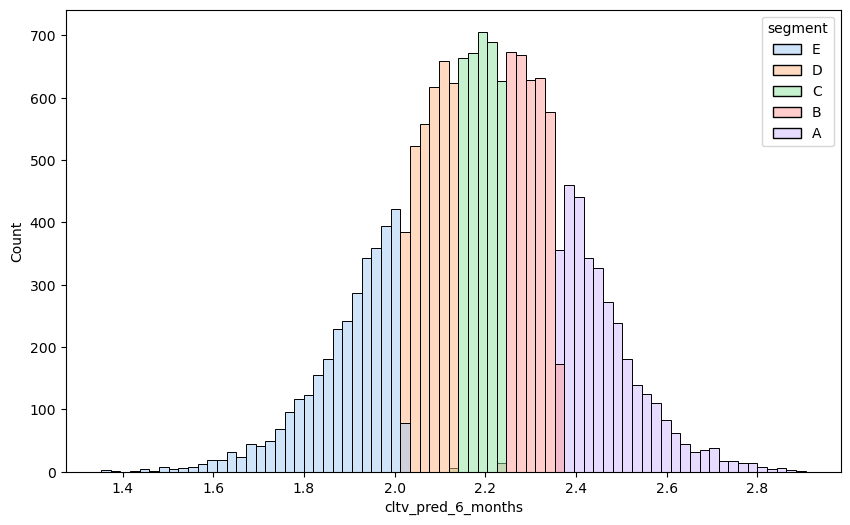

In [125]:
# 정규 분포 모양의 히스토그램 도출
# 등급이 높은 A나 낮은 E의 경우 그룹내에서도 편차가 큼
plt.figure(figsize=(10, 6))

sns.histplot(x=np.log10(flo_cltv2['cltv_pred_6_months']),
             hue=flo_cltv2['segment'],
             palette='pastel')

plt.show()

In [135]:
# 처음 수기로 구한 CLTV와 비교
flo_cltv2_2020 = flo_cltv2[(flo_cltv2['first_order_date'] >= event_start) & (flo_cltv2['last_order_date'] <= event_end)].reset_index(drop=True)

In [136]:
comp_1 = flo_cltv.sort_values(by='CLTV', ascending=False)[columns].head(50).reset_index(drop=True)
comp_2 = flo_cltv2_2020.sort_values(by='cltv_pred_6_months', ascending=False).head(50).reset_index(drop=True)

In [138]:
# 겹치는 고객 8명
len(set(comp_1['master_id']) & set(comp_2['master_id']))

8

In [139]:
# 총 구매 금액과 구매 빈도 비교
# 매우 유사함!
print(comp_1['customer_value_total'].mean())
print(comp_1['frequency'].mean(), '\n')

print(comp_2['customer_value_total'].mean())
print(comp_2['frequency'].mean())

823.2472
2.86 

997.3019999999998
2.64
